### JRCLUST: Bundled vs Linear 

In [80]:
from extract_data import *
import matplotlib.pyplot as plt
from compare_data import * 
import numpy as np
import bombcell as bc

In [81]:
# load data that will be used throughout the notebook 
linear_prm_path = r"/Volumes/Trenholm2/neuroTechData/jun16_data/Viktor_08_sortings/linear_5_5_JRCLUST/linear_5_5_amp.prm"
siteLoc_linear, siteMap_linear, sampleRate_linear = get_prm_info(linear_prm_path)
linear_res_mat_path = r"/Volumes/Trenholm2/neuroTechData/jun16_data/Viktor_08_sortings/linear_5_5_JRCLUST/linear_5_5_amp_res.mat"
linear_spikesFilt_path = r"/Volumes/Trenholm2/neuroTechData/jun16_data/Viktor_08_sortings/linear_5_5_JRCLUST/linear_5_5_spikesFilt.mat"

bundled_prm_path = r"/Volumes/Trenholm2/neuroTechData/jun16_data/Viktor_08_sortings/bundled_5_5_JRCLUST/bundled_5_5_amp.prm"
siteLoc_bundled, siteMap_bundled, sampleRate_bundled = get_prm_info(bundled_prm_path)
bundled_res_mat_path = r"/Volumes/Trenholm2/neuroTechData/jun16_data/Viktor_08_sortings/bundled_5_5_JRCLUST/bundled_5_5_amp_res.mat"
bundled_spikesFilt_path = r"/Volumes/Trenholm2/neuroTechData/jun16_data/Viktor_08_sortings/bundled_5_5_JRCLUST/bundled_5_5_spikesFilt.mat"

recording_duration = 3794.32

In [29]:
siteLoc_bundled.shape

(64, 2)

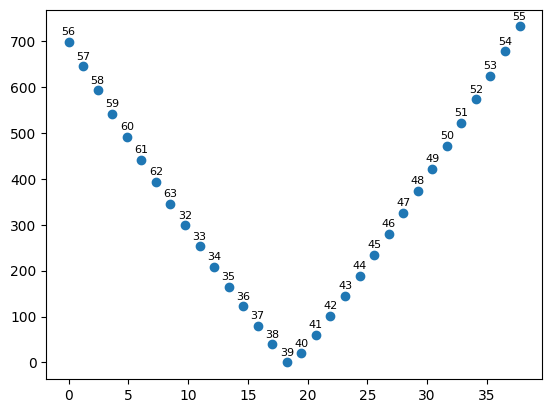

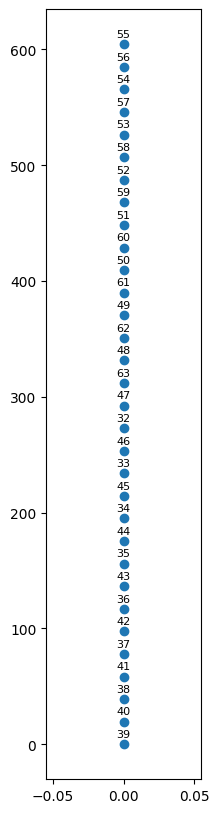

In [38]:
plt.figure()
plt.scatter(siteLoc_bundled[:32, 0], siteLoc_bundled[:32, 1])

for x, y, label in zip(siteLoc_bundled[:32, 0], siteLoc_bundled[:32, 1], siteMap_bundled[32:]):
    plt.annotate(str(label), (x, y), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=8)

plt.show()

plt.figure(figsize=(2,10))
plt.scatter(siteLoc_linear[:32, 0], siteLoc_linear[:32, 1])

for x, y, label in zip(siteLoc_linear[:32, 0], siteLoc_linear[:32, 1], siteMap_linear[32:]):
    plt.annotate(str(label), (x, y), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=8)

plt.show()

***
### Determine which units and spikes could be potential matches between the two probe types 

In [82]:
b_cluster_data =  extract_cluster_data_JRCLUST(bundled_res_mat_path, siteMap_bundled)
print(f"JRCLUST bundled units ({len(b_cluster_data[0])}): {b_cluster_data[0]}")
b_total_spike_num = len(b_cluster_data[0])

l_cluster_data = extract_cluster_data_JRCLUST(linear_res_mat_path, siteMap_linear)
print(f"JRCLUST linear units ({len(l_cluster_data[0])}): {l_cluster_data[0]}")
l_total_spike_num = len(l_cluster_data[0])

Total spike num: (1, 726205)
JRCLUST bundled units (45): [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]
Total spike num: (1, 722054)
JRCLUST linear units (39): [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]


In [83]:
bundled_spike_clusters = []
with h5py.File(Path(bundled_res_mat_path), "r") as f:
    bundled_spike_clusters = f["spikeClusters"][...]

linear_spike_clusters = []
with h5py.File(Path(linear_res_mat_path), "r") as f:
    linear_spike_clusters = f["spikeClusters"][...]

In [5]:
print(f"{726205 - 722054} more spikes were found when the bundled geom than with the linear geom")

print("Let's first see which spikes are the same between the two geometries (including a tolerance).")

4151 more spikes were found when the bundled geom than with the linear geom
Let's first see which spikes are the same between the two geometries (including a tolerance).


In [84]:
d = []
s = [] 

for res_p in [bundled_res_mat_path, linear_res_mat_path]:
    res_file = Path(res_p)

    with h5py.File(res_file, "r") as f:
        spike_times    = f["spikeTimes"][...].squeeze() - 1
        spike_sites    = f["spikeSites"][...].squeeze().ravel().astype("int32") - 1  # → python index into siteMap
        d.append(spike_times)
        s.append(spike_sites)

print("Are there any duplicate spikes?")
b_spike_sampleAndChan = np.column_stack((d[0], s[0])) # final shape: n_spikes, 2 (spike sample, chan)
l_spike_sampleAndChan = np.column_stack((d[1], s[1]))

unique_b_spike_samples, b_unique_indicies = np.unique(b_spike_sampleAndChan, axis=0, return_index=True) # d[0]
unique_l_spike_samples, l_unique_indices  = np.unique(l_spike_sampleAndChan, axis=0, return_index=True) # d[1]

print(f"unique b spike num: {len(unique_b_spike_samples)}. {726205 - len(unique_b_spike_samples)} non-unique spikes.\nunique l spike num: {len(unique_l_spike_samples)}. {722054 - len(unique_l_spike_samples)} non-unique spikes.")
print("Answer: No, there are no duplicate spikes ;)")

Are there any duplicate spikes?
unique b spike num: 726205. 0 non-unique spikes.
unique l spike num: 722054. 0 non-unique spikes.
Answer: No, there are no duplicate spikes ;)


In [85]:
matches_spikeTime = identical_spikes(d[0], d[1], tol=0)
matches_spikeTime_andChan = identical_spikes(spike_times_A=d[0], spike_times_B=d[1], tol=0, channels_A=s[0], channels_B=s[1])

print(f"With a tolerance of 0 samples, {matches_spikeTime.shape[0]} spikes times were found to be identical.")
print(f"This is the same number of spikes as found in total with the linear geometry.")
print("We can now compare the cluster_id, location, peak_channel, and waveform differences between 'matching' and 'non-matching' spikes")

print ("--------------")
print("If we consider indtical to mean in sample AND in spike peak channel:")
print(f"With a tolerance of 0 samples, {matches_spikeTime_andChan.shape[0]} spikes were found to be identical.")

print("this means that the indentical spikes are indeed indentical in chan too.")

With a tolerance of 0 samples, 722054 spikes times were found to be identical.
This is the same number of spikes as found in total with the linear geometry.
We can now compare the cluster_id, location, peak_channel, and waveform differences between 'matching' and 'non-matching' spikes
--------------
If we consider indtical to mean in sample AND in spike peak channel:
With a tolerance of 0 samples, 722054 spikes were found to be identical.
this means that the indentical spikes are indeed indentical in chan too.


We'll start by looking into the non-matched spikes to see in what ways they are different from those that are matched

399 of the 4151 unmatched spikes are present in the linear spike times


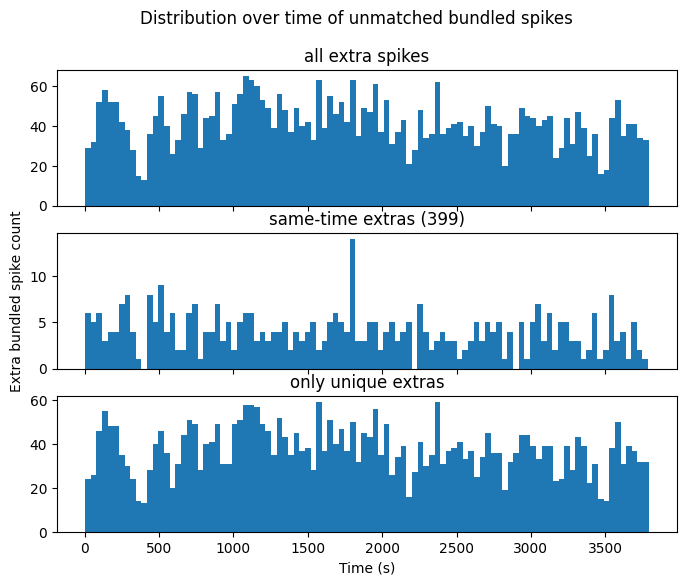

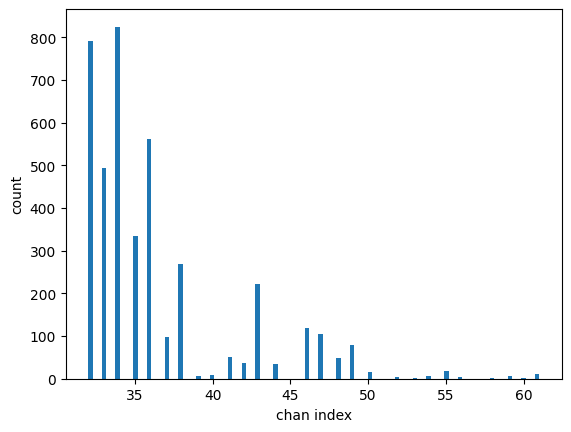

[32 33 34 35 36 37 38 39 40 41 42 43 44 46 47 48 49 50 52 53 54 55 56 58
 59 60 61]
27


In [39]:
b_spikes = d[0] 
b_chans = s[0]
l_spikes = d[1]
l_chans = s[1]

bundled_match_idx = matches_spikeTime_andChan[:,0]
linear_match_idx = matches_spikeTime_andChan[:,1]

bundled_mask = np.ones(len(b_spikes), dtype=bool)
bundled_mask[bundled_match_idx] = False

unmatched_samples = b_spikes[bundled_mask]
unmatched_channels = b_chans[bundled_mask]
matched_channels = b_chans[~bundled_mask]
print(f"{np.sum(np.isin(unmatched_samples, l_spikes))} of the {len(unmatched_samples)} unmatched spikes are present in the linear spike times")

fs = 20000

# where do the unmatched samples occur in the recording 
all_unmatched_seconds = unmatched_samples / fs
same_time_extras = unmatched_samples[np.isin(unmatched_samples, l_spikes)] / fs 
new_time_extras = unmatched_samples[~np.isin(unmatched_samples, l_spikes)] / fs 


fig, axes = plt.subplots(3,1 , figsize=(8,6), sharex=True)
axes[0].hist(all_unmatched_seconds, bins=100)
axes[0].set_title("all extra spikes")
axes[1].hist(same_time_extras, bins=100)
axes[1].set_title("same-time extras (399)")
axes[2].hist(new_time_extras, bins=100)
axes[2].set_title("only unique extras")
plt.xlabel("Time (s)")
axes[1].set_ylabel("Extra bundled spike count")
plt.suptitle(f"Distribution over time of unmatched bundled spikes")
plt.show()

plt.figure()
plt.hist(unmatched_channels, bins=100)
plt.ylabel("count")
plt.xlabel("chan index")
plt.show()
print(np.unique(unmatched_channels))
print(len(np.unique(unmatched_channels)))

In [28]:
bin_size = 5  # seconds — adjust to taste
bins = np.arange(0, recording_duration + bin_size, bin_size)
counts, _ = np.histogram(all_unmatched_seconds, bins=bins)
presence_ratio = np.mean(counts > 0)
n_bins = len(counts)
print(f"Presence ratio: {presence_ratio:.3f} ({presence_ratio*100:.1f}% of {n_bins} bins)")

Presence ratio: 0.980 (98.0% of 759 bins)


In [24]:
from collections import Counter

chan_counts = Counter(unmatched_channels)
total = sum(chan_counts.values())

# What fraction of extra spikes come from the top N channels?
top5 = sum(v for _, v in chan_counts.most_common(5))
print(f"Top 5 channels account for {100*top5/total:.1f}% of extra spikes")
print(f"Channels represented: {len(chan_counts)} of 30")

Top 5 channels account for 72.4% of extra spikes
Channels represented: 27 of 30


We see that the unmatched spikes are rather uniformly distributed suggesting that they are not due to startup effects, drift, or other state-dependent effects.

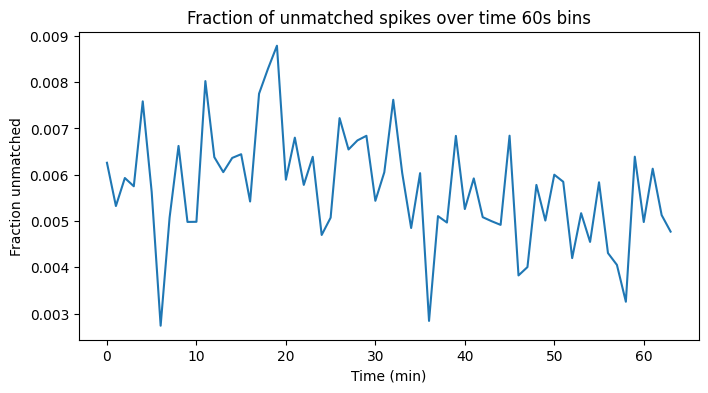

In [8]:
bin_size_sec = 60

bins = np.arange(
    0,
    b_spikes.max()/fs + bin_size_sec,
    bin_size_sec
)

unmatched_counts, _ = np.histogram(
    all_unmatched_seconds,
    bins=bins
)

all_counts, _ = np.histogram(
    b_spikes/fs,
    bins=bins
)

fraction = unmatched_counts / all_counts

plt.figure(figsize=(8,4))
plt.plot(bins[:-1]/60, fraction)
plt.title("Fraction of unmatched spikes over time 60s bins")
plt.xlabel("Time (min)")
plt.ylabel("Fraction unmatched")
plt.show()

Are these unmatched spikes almost duplicates ? 
We already know 399 spikes are identical to spikes already existing but what about the 3752 others? 

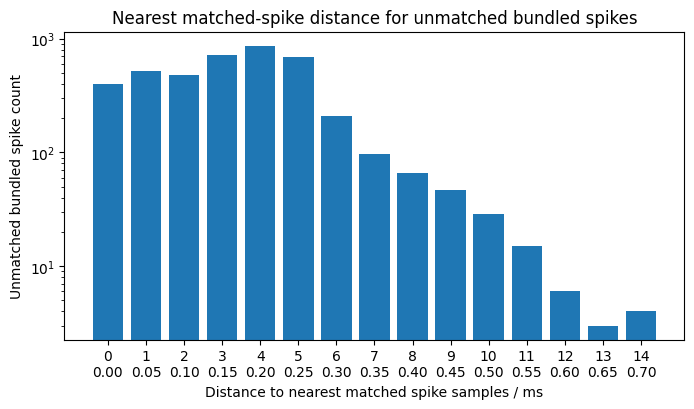

Unique nearest sample distances: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [42]:
fs =20000

matched_times = np.sort(b_spikes[bundled_match_idx])
unmatched_samples = np.sort(unmatched_samples)

idx = np.searchsorted(matched_times, unmatched_samples)

left = np.maximum(idx - 1, 0)
right = np.minimum(idx, len(matched_times) - 1)

nearest_dist = np.minimum(
    np.abs(unmatched_samples - matched_times[left]),
    np.abs(unmatched_samples - matched_times[right])
)

counts = np.bincount(nearest_dist)
distances = np.arange(len(counts))

plt.figure(figsize=(8, 4))
plt.bar(distances, counts)
plt.yscale("log")
plt.xticks(distances)
plt.xlabel("Distance to nearest matched spike samples / ms")
plt.xticks(distances, [f"{d}\n{d/fs*1000:.2f}" for d in distances])
plt.ylabel("Unmatched bundled spike count")
plt.title("Nearest matched-spike distance for unmatched bundled spikes")
plt.show()


print(f"Unique nearest sample distances: {np.unique(nearest_dist)}")



In [43]:
fs = 20_000
near_thresh = 5

n_total = len(nearest_dist)
n_same_time = np.sum(nearest_dist == 0)
n_near = np.sum(nearest_dist <= near_thresh)
n_far = np.sum(nearest_dist > near_thresh)

print(f"Total unmatched bundled spikes: {n_total}")
print(f"Same-sample extras: {n_same_time} ({n_same_time/n_total:.2%})")
print(f"Within ±{near_thresh} samples ({near_thresh/fs*1000:.2f} ms): {n_near} ({n_near/n_total:.2%})")
print(f"> {near_thresh} samples: {n_far} ({n_far/n_total:.2%})")

for thresh in [1, 5, 10]:
    n = np.sum(nearest_dist <= thresh)
    print(f"≤ {thresh} samples ({thresh/fs*1000:.2f} ms): {n} / {n_total} = {n/n_total:.2%}")

Total unmatched bundled spikes: 4151
Same-sample extras: 399 (9.61%)
Within ±5 samples (0.25 ms): 3676 (88.56%)
> 5 samples: 475 (11.44%)
≤ 1 samples (0.05 ms): 919 / 4151 = 22.14%
≤ 5 samples (0.25 ms): 3676 / 4151 = 88.56%
≤ 10 samples (0.50 ms): 4123 / 4151 = 99.33%


In [ ]:
# For each unmatched spike, find the actual nearest matched spike index
# and compute the channel distance
idx_clipped = np.clip(np.searchsorted(matched_times, unmatched_samples), 0, len(matched_times)-1)

# Get channel of each unmatched spike and its nearest matched spike
unmatched_chans_arr = np.array([unmatched_channels[i] for i in range(len(unmatched_samples))])
matched_chans_arr = np.array([matched_channels[i] for i in range(len(matched_times))])  

nearest_chan_dist = np.abs(unmatched_chans_arr - matched_chans_arr[idx_clipped])

close_mask = nearest_dist <= 5
print(f"Of spikes within 5 samples, mean channel distance: {nearest_chan_dist[close_mask].mean():.1f}")
print(f"Of spikes within 5 samples, same channel: {(nearest_chan_dist[close_mask]==0).sum()}")
print(f"Of spikes within 5 samples, ≤2 channels away: {(nearest_chan_dist[close_mask]<=2).sum()}")

Of spikes within 5 samples, mean channel distance: 8.7
Of spikes within 5 samples, same channel: 29
Of spikes within 5 samples, ≤2 channels away: 189


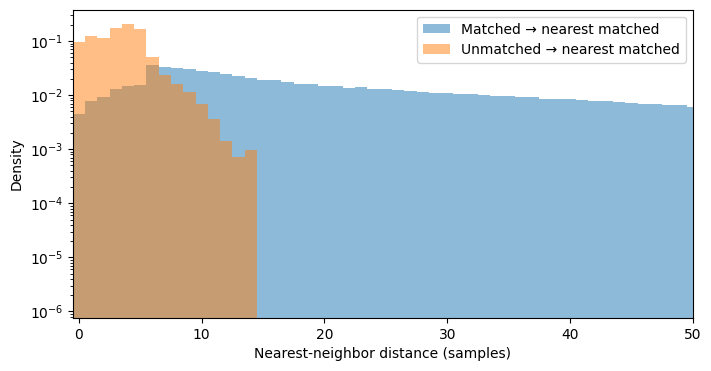

In [11]:
def nearest_neighbor_dist_same_array(times):
    times = np.sort(np.asarray(times))
    prev_dist = np.r_[np.inf, np.diff(times)]
    next_dist = np.r_[np.diff(times), np.inf]
    return np.minimum(prev_dist, next_dist)

matched_times = np.sort(b_spikes[bundled_match_idx])
matched_nn_dist = nearest_neighbor_dist_same_array(matched_times)

plt.figure(figsize=(8, 4))

bins = np.arange(0, max(nearest_dist.max(), matched_nn_dist.max()) + 2) - 0.5

plt.hist(
    matched_nn_dist,
    bins=bins,
    alpha=0.5,
    density=True,
    label="Matched → nearest matched"
)

plt.hist(
    nearest_dist,
    bins=bins,
    alpha=0.5,
    density=True,
    label="Unmatched → nearest matched"
)

plt.xlim(-0.5, 50)
plt.yscale("log")
plt.xlabel("Nearest-neighbor distance (samples)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [12]:
for thresh in [1, 5, 10]:
    p_unmatched = np.mean(nearest_dist <= thresh)
    p_matched = np.mean(matched_nn_dist <= thresh)

    print(
        f"≤ {thresh} samples: "
        f"unmatched={p_unmatched:.2%}, "
        f"matched baseline={p_matched:.2%}, "
        f"ratio={p_unmatched / p_matched:.2f}x"
    )

≤ 1 samples: unmatched=22.14%, matched baseline=1.23%, ratio=17.94x
≤ 5 samples: unmatched=88.56%, matched baseline=6.50%, ratio=13.63x
≤ 10 samples: unmatched=99.33%, matched baseline=22.51%, ratio=4.41x


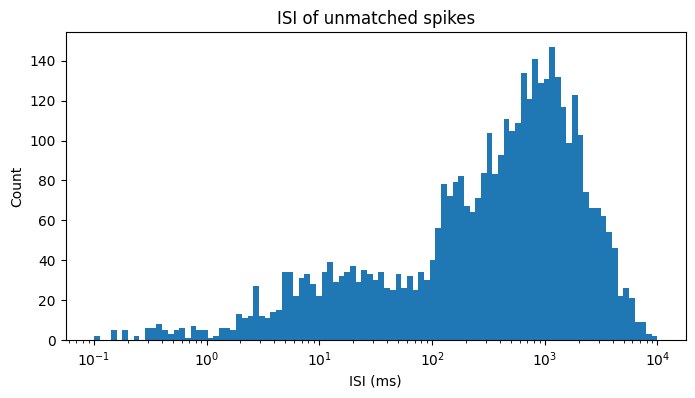

In [13]:
isi = np.diff(unmatched_samples) / fs * 1000 # in ms 

plt.figure(figsize=(8,4))
plt.hist(isi, bins=np.logspace(-1,4,100))
plt.title("ISI of unmatched spikes")
plt.xscale("log")
plt.xlabel("ISI (ms)")
plt.ylabel("Count")
plt.show()

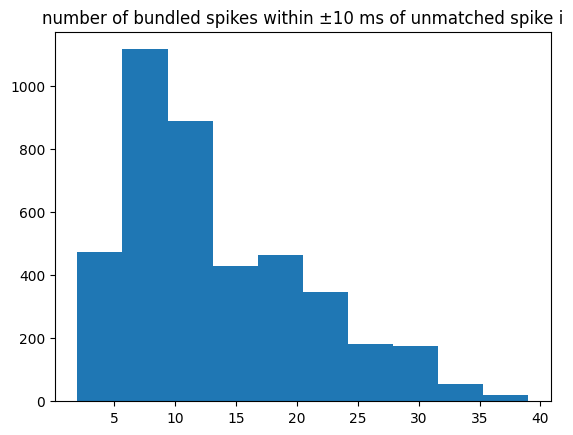

In [14]:
window = int(0.01 * fs)  # 10 ms

left = np.searchsorted(
    b_spikes,
    unmatched_samples - window
)

right = np.searchsorted(
    b_spikes,
    unmatched_samples + window
)

local_density = right - left

plt.figure()
plt.hist(local_density)
plt.title("number of bundled spikes within ±10 ms of unmatched spike i")
plt.show()

Are there amplitude differences between the matched and unmatched spikes?

(1, 722054)
(1, 4151)


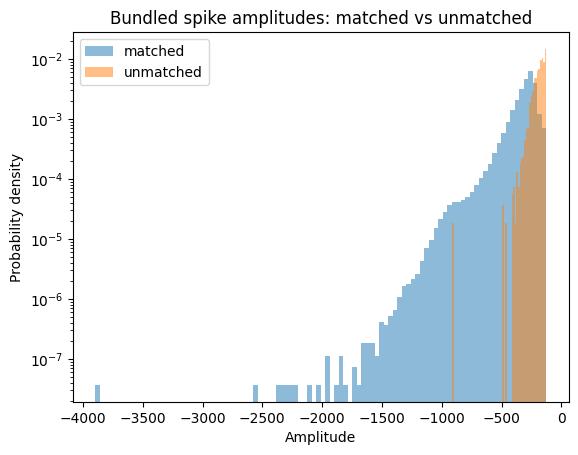

In [48]:
a = []

for res_p in [bundled_res_mat_path, linear_res_mat_path]:
    res_file = Path(res_p)

    with h5py.File(res_file, "r") as f:
        a.append(f["spikeAmps"][...].squeeze())

b_amps = a[0]
bundled_mask = np.ones(len(b_amps), dtype=bool)
bundled_mask[bundled_match_idx] = False

unmatched_samples = b_spikes[bundled_mask]
bundled_matched_spike_amps = np.array([b_amps[~bundled_mask]])
print(bundled_matched_spike_amps.shape) # (1, 722054)
bundled_unmatched_spike_amps = np.array([b_amps[bundled_mask]])
print(bundled_unmatched_spike_amps.shape) # (1, 4151)

plt.figure()
plt.hist(bundled_matched_spike_amps.ravel(), bins=100, density=True, alpha=0.5, label="matched")

plt.hist(bundled_unmatched_spike_amps.ravel(), bins=60, density=True, alpha=0.5, label="unmatched")
plt.yscale("log")
plt.title("Bundled spike amplitudes: matched vs unmatched")
plt.legend()
plt.xlabel("Amplitude")
plt.ylabel("Probability density")
plt.show()


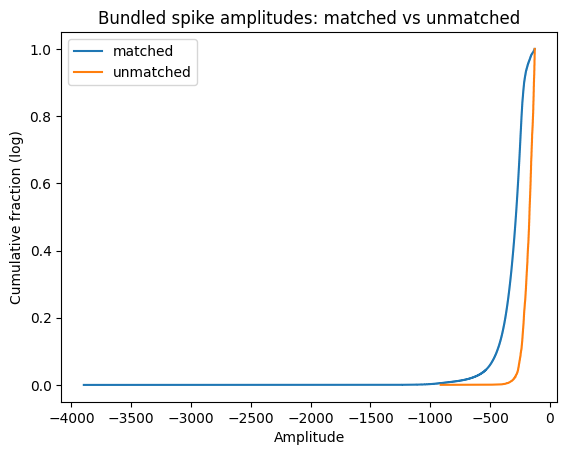

In [49]:
from statsmodels.distributions.empirical_distribution import ECDF

ecdf_m = ECDF(bundled_matched_spike_amps.ravel())
ecdf_u = ECDF(bundled_unmatched_spike_amps.ravel())

plt.figure()

plt.plot(ecdf_m.x, ecdf_m.y, label="matched")
plt.plot(ecdf_u.x, ecdf_u.y, label="unmatched")

plt.xlabel("Amplitude")
plt.ylabel("Cumulative fraction (log)")
plt.title("Bundled spike amplitudes: matched vs unmatched")
plt.legend()
plt.show()

In [50]:
for name, amps in {
    "matched": bundled_matched_spike_amps.ravel(),
    "unmatched": bundled_unmatched_spike_amps.ravel(),
}.items():

    print(name)
    print("median", np.median(amps))
    print("mean", np.mean(amps))
    print("5th", np.percentile(amps,5))
    print("95th", np.percentile(amps,95))
    print()

matched
median -285.0
mean -313.6951585338493
5th -521.0
95th -187.0

unmatched
median -172.0
mean -182.14598891833293
5th -264.0
95th -130.0



In [53]:
from scipy import stats

ks_stat, p_val = stats.ks_2samp(
    bundled_matched_spike_amps.ravel(),
    bundled_unmatched_spike_amps.ravel()
)
print(f"KS statistic: {ks_stat:.4f}, p = {p_val:.2e}")

KS statistic: 0.7043, p = 0.00e+00


From the above results, it's clear that detection of large amplitude spikes are detected by both geometries. The bundled geometry unique spikes that have no linear match, tend to be smaller in amplitude. 

We now look at the waveforms of the unmatched and matched spikes. Reminder that we have 4151 more spikes in the bundled than in the linear. Of these 4151, 339 of them are at the same site as spikes detected in linear (may be different channel but they're at the same sample index). We can then analyze the remaining 3812 extra spikes and see whether these are valid waveforms.

In [55]:
# unmatched_samples
#   - check waveform PCA
from sklearn.decomposition import PCA 

# collect all peak channel waveforms from both sortings 
b_data = loadmat(bundled_spikesFilt_path)
res = b_data['res']['spikesFilt'][0,0]
b_waveforms = res[:, 0, :].T # 41 x 12 x spike num --> spikenum x 41 

b_unmatched_waveforms = b_waveforms[bundled_mask]
b_matched_waveforms = b_waveforms[~bundled_mask]

# fit PCA on full pool
pca = PCA(n_components = 12)
pca.fit(b_waveforms)

,n_components,12
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


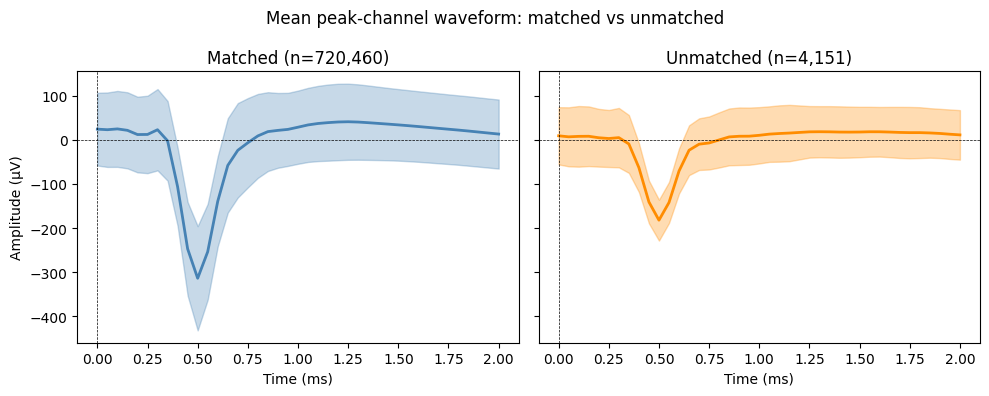

In [56]:
mean_matched   = b_matched_waveforms.mean(axis=0)
std_matched    = b_matched_waveforms.std(axis=0)
mean_unmatched = b_unmatched_waveforms.mean(axis=0)
std_unmatched  = b_unmatched_waveforms.std(axis=0)

t = np.arange(b_waveforms.shape[1]) / fs * 1000  # ms

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, mean, std, label, color in zip(
    axes,
    [mean_matched, mean_unmatched],
    [std_matched, std_unmatched],
    ["Matched (n=720,460)", "Unmatched (n=4,151)"],
    ["steelblue", "darkorange"]
):
    ax.plot(t, mean, color=color, lw=2)
    ax.fill_between(t, mean - std, mean + std, alpha=0.3, color=color)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.axvline(0, color='k', lw=0.5, ls='--')
    ax.set_title(label)
    ax.set_xlabel("Time (ms)")

axes[0].set_ylabel("Amplitude (μV)")
plt.suptitle("Mean peak-channel waveform: matched vs unmatched")
plt.tight_layout()
plt.show()

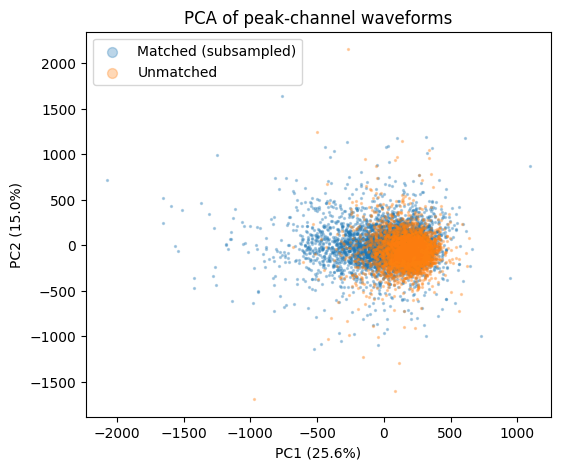

In [63]:
# subsample matched to same n as unmatched for fair visual comparison
np.random.seed(42)
idx_sub = np.random.choice(len(b_matched_waveforms), 
                           size=len(b_unmatched_waveforms), 
                           replace=False)

proj = pca.transform(b_waveforms)
proj_matched_sub  = proj[~bundled_mask][idx_sub]
proj_unmatched    = proj[bundled_mask]

plt.figure(figsize=(6,5))
plt.scatter(proj_matched_sub[:,0],  proj_matched_sub[:,1],  
            s=2, alpha=0.3, label="Matched (subsampled)")
plt.scatter(proj_unmatched[:,0],    proj_unmatched[:,1],    
            s=2, alpha=0.3, label="Unmatched")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(markerscale=5)
plt.title("PCA of peak-channel waveforms")
plt.show()

PCs needed for 90% variance: 12
Variance per component: [0.256 0.15  0.12  0.084 0.061 0.051 0.045 0.035 0.029 0.028 0.023 0.022]


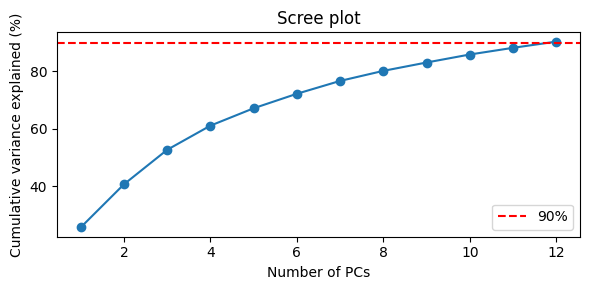

In [58]:
# use as pca.transform later on each unit to get the pca features 
cumvar = np.cumsum(pca.explained_variance_ratio_)

# find how many PCs to reach 90% variance
n_90 = np.searchsorted(cumvar, 0.90) + 1
print(f"PCs needed for 90% variance: {n_90}")
print(f"Variance per component: {np.round(pca.explained_variance_ratio_, 3)}")

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(np.arange(1, len(cumvar)+1), cumvar * 100, marker='o')
plt.axhline(90, color='r', linestyle='--', label='90%')
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative variance explained (%)")
plt.title("Scree plot")
plt.legend()
plt.tight_layout()
plt.show()

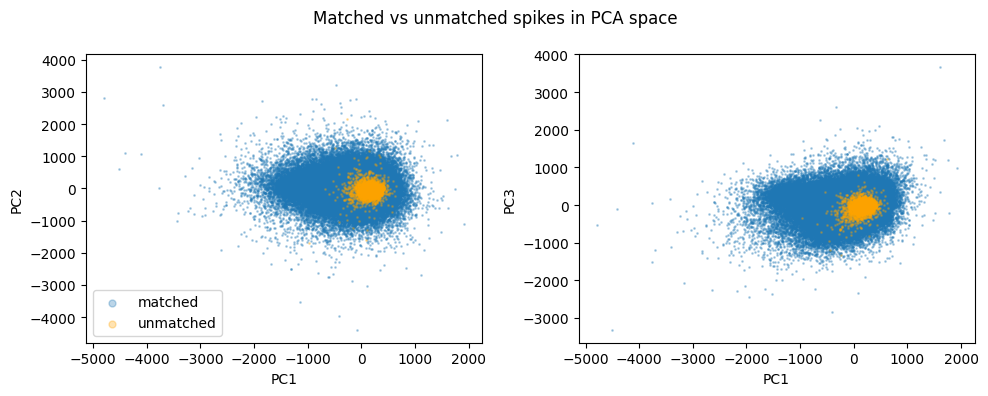

In [59]:
pca.fit(b_waveforms)

matched_pcs   = pca.transform(b_matched_waveforms)
unmatched_pcs = pca.transform(b_unmatched_waveforms)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (xi, yi, xlabel, ylabel) in zip(axes, [
    (0, 1, "PC1", "PC2"),
    (0, 2, "PC1", "PC3"),
]):
    ax.scatter(matched_pcs[:,xi],   matched_pcs[:,yi],
               s=1, alpha=0.3, label="matched")
    ax.scatter(unmatched_pcs[:,xi], unmatched_pcs[:,yi],
               s=1, alpha=0.3, label="unmatched", color="orange")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

axes[0].legend(markerscale=5)
plt.suptitle("Matched vs unmatched spikes in PCA space")
plt.tight_layout()
plt.show()

In [64]:
n_components = 10
pc_cols = [f"PC{i+1}" for i in range(n_components)]

df_pcs = pd.DataFrame({
    "group":    ["matched"] * len(matched_pcs) + ["unmatched"] * len(unmatched_pcs),
    **{f"PC{i+1}": np.concatenate([matched_pcs[:, i], unmatched_pcs[:, i]])
       for i in range(n_components)}
})

df_pcs.groupby("group")[pc_cols].mean().T

group,matched,unmatched
PC1,-1.009833,175.657410
PC2,0.357246,-62.141938
PC3,0.226144,-39.337029
PC4,-0.695500,120.980097
PC5,0.292305,-50.845566
PC6,0.173986,-30.264299
PC7,-0.162520,28.269932
PC8,0.043641,-7.591175
PC9,-0.099751,17.351378
PC10,-0.028750,5.001010


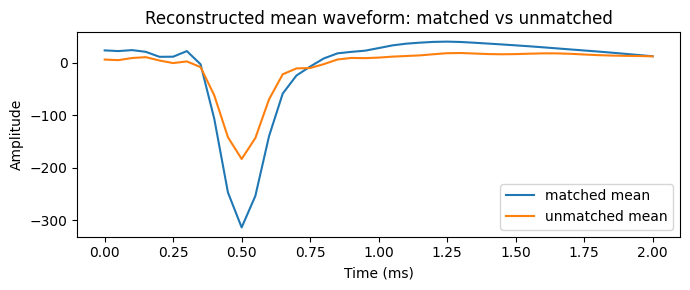

In [26]:
mean_unmatched_pcs = unmatched_pcs.mean(axis=0)   # (n_components,)
mean_matched_pcs   = matched_pcs.mean(axis=0)

# project back to waveform space
mean_unmatched_wf = pca.inverse_transform(mean_unmatched_pcs)  # (41,)
mean_matched_wf   = pca.inverse_transform(mean_matched_pcs)

t_ms = np.arange(41) / 20000 * 1000   # time in ms

plt.figure(figsize=(7, 3))
plt.plot(t_ms, mean_matched_wf,   label="matched mean")
plt.plot(t_ms, mean_unmatched_wf, label="unmatched mean")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Reconstructed mean waveform: matched vs unmatched")
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
# Compare spread (std) in PC space as evidence of coherence
print("PC1 std — matched: {:.1f}, unmatched: {:.1f}".format(matched_pcs[:,0].std(), unmatched_pcs[:,0].std()))
print("PC2 std — matched: {:.1f}, unmatched: {:.1f}".format(matched_pcs[:,1].std(), unmatched_pcs[:,1].std()))
print("PC3 std — matched: {:.1f}, unmatched: {:.1f}".format(matched_pcs[:,2].std(), unmatched_pcs[:,2].std()))
print("PC4 std — matched: {:.1f}, unmatched: {:.1f}".format(matched_pcs[:,3].std(), unmatched_pcs[:,3].std()))

PC1 std — matched: 286.2, unmatched: 134.3
PC2 std — matched: 219.1, unmatched: 172.0
PC3 std — matched: 196.1, unmatched: 139.3
PC4 std — matched: 163.9, unmatched: 101.6


## Figure 1. 

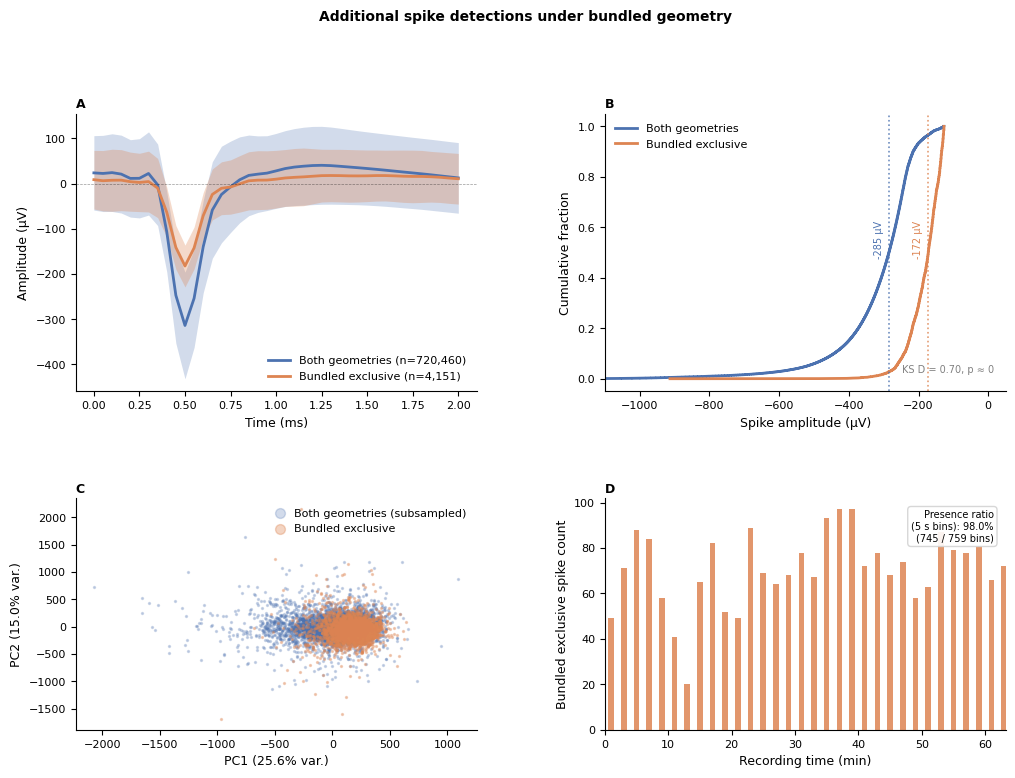

Saved: unmatched_spikes_evidence.pdf / .png


In [72]:
"""
Multipanel figure: evidence that additional bundled geometry detections
are of neural rather than noise origin.

Panels:
  A (top-left)  — Mean ± std peak-channel waveform, matched vs unmatched
  B (top-right) — Spike amplitude ECDF, matched vs unmatched
  C (bot-left)  — PCA scatter, matched (subsampled) vs unmatched
  D (bot-right) — Temporal distribution of unmatched spikes

Assumes the following variables are already in scope:
  b_matched_waveforms        : ndarray (720460, 41)
  b_unmatched_waveforms      : ndarray (4151,   41)
  bundled_matched_spike_amps : ndarray (1, 720460) or (720460,)
  bundled_unmatched_spike_amps: ndarray (1, 4151)  or (4151,)
  matched_pcs                : ndarray (720460, n_components)
  unmatched_pcs              : ndarray (4151,   n_components)
  pca                        : fitted sklearn PCA object
  all_unmatched_seconds      : ndarray (4151,) — spike times in seconds
  recording_duration         : float  — 3794.32 s
  fs                         : int    — 20000 Hz
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.distributions.empirical_distribution import ECDF

# ── Shared style ──────────────────────────────────────────────────────────────
COL_M  = '#4C72B0'   # matched:   blue
COL_U  = '#DD8452'   # unmatched: orange
FS_LABEL = 9
FS_TICK  = 8

plt.rcParams.update({
    'font.size':        FS_LABEL,
    'axes.titlesize':   FS_LABEL,
    'axes.labelsize':   FS_LABEL,
    'xtick.labelsize':  FS_TICK,
    'ytick.labelsize':  FS_TICK,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 8))
gs  = gridspec.GridSpec(
    2, 2,
    figure       = fig,
    height_ratios= [1.2, 1],   # waveform row slightly taller
    hspace       = 0.42,
    wspace       = 0.32,
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# ── Panel A: Mean ± std waveform ──────────────────────────────────────────────
t = np.arange(b_matched_waveforms.shape[1]) / fs * 1000   # samples → ms

mean_m, std_m = b_matched_waveforms.mean(0),   b_matched_waveforms.std(0)
mean_u, std_u = b_unmatched_waveforms.mean(0), b_unmatched_waveforms.std(0)

ax_a.fill_between(t, mean_m - std_m, mean_m + std_m,
                  alpha=0.25, color=COL_M,  linewidth=0)
ax_a.fill_between(t, mean_u - std_u, mean_u + std_u,
                  alpha=0.30, color=COL_U,  linewidth=0)
ax_a.plot(t, mean_m, color=COL_M, lw=2.0,
          label=f'Both geometries (n=720,460)')
ax_a.plot(t, mean_u, color=COL_U, lw=2.0,
          label=f'Bundled exclusive (n=4,151)')
ax_a.axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)
ax_a.set_xlabel('Time (ms)')
ax_a.set_ylabel('Amplitude (μV)')
ax_a.set_title('A', loc='left', fontweight='bold', pad=4)
ax_a.legend(fontsize=FS_TICK, frameon=False, loc='lower right')

# ── Panel B: Amplitude ECDF ───────────────────────────────────────────────────
amps_m = bundled_matched_spike_amps.ravel()
amps_u = bundled_unmatched_spike_amps.ravel()

ecdf_m = ECDF(amps_m)
ecdf_u = ECDF(amps_u)

ax_b.plot(ecdf_m.x, ecdf_m.y, color=COL_M, lw=2.0, label='Both geometries')
ax_b.plot(ecdf_u.x, ecdf_u.y, color=COL_U, lw=2.0, label='Bundled exclusive')

# Median marker lines
for ax_, val, col in [(ax_b, np.median(amps_m), COL_M),
                      (ax_b, np.median(amps_u), COL_U)]:
    ax_.axvline(val, color=col, lw=1.2, ls=':', alpha=0.8)
    ax_.text(val - 15, 0.55, f'{val:.0f} μV',
             color=col, fontsize=7, ha='right', va='center', rotation=90)

ax_b.set_xlim(-1100, 50)
ax_b.set_xlabel('Spike amplitude (μV)')
ax_b.set_ylabel('Cumulative fraction')
ax_b.set_title('B', loc='left', fontweight='bold', pad=4)
ax_b.legend(fontsize=FS_TICK, frameon=False)
ax_b.text(0.97, 0.06,
          f'KS D = 0.70, p ≈ 0',
          transform=ax_b.transAxes,
          ha='right', va='bottom', fontsize=7, color='grey')

# ── Panel C: PCA scatter ──────────────────────────────────────────────────────
np.random.seed(42)
n_sub   = len(unmatched_pcs)
idx_sub = np.random.choice(len(matched_pcs), size=n_sub, replace=False)

ax_c.scatter(matched_pcs[idx_sub, 0], matched_pcs[idx_sub, 1],
             s=2, alpha=0.25, color=COL_M, rasterized=True,
             label='Both geometries (subsampled)')
ax_c.scatter(unmatched_pcs[:, 0], unmatched_pcs[:, 1],
             s=2, alpha=0.35, color=COL_U, rasterized=True,
             label='Bundled exclusive')

ax_c.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax_c.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax_c.set_title('C', loc='left', fontweight='bold', pad=4)
ax_c.legend(fontsize=FS_TICK, frameon=False,
            markerscale=5, handletextpad=0.3)

# ── Panel D: Temporal distribution ───────────────────────────────────────────
bin_size_s  = 60           # 1-minute bins for clean bar display
bins        = np.arange(0, recording_duration + bin_size_s, bin_size_s)
counts, edges = np.histogram(all_unmatched_seconds, bins=bins)
bin_centers   = (edges[:-1] + edges[1:]) / 60   # convert to minutes

ax_d.bar(bin_centers, counts,
         width = bin_size_s / 60 * 0.88,
         color = COL_U, alpha=0.85, linewidth=0)

ax_d.set_xlabel('Recording time (min)')
ax_d.set_ylabel('Bundled exclusive spike count')
ax_d.set_title('D', loc='left', fontweight='bold', pad=4)
ax_d.set_xlim(0, recording_duration / 60)

# Annotate presence ratio (computed with 5 s bins)
ax_d.text(0.97, 0.95,
          'Presence ratio\n(5 s bins): 98.0%\n(745 / 759 bins)',
          transform = ax_d.transAxes,
          ha='right', va='top', fontsize=7,
          bbox=dict(boxstyle='round,pad=0.35',
                    facecolor='white', edgecolor='lightgrey', alpha=0.9))

# ── Supertitle ────────────────────────────────────────────────────────────────
fig.suptitle(
    'Additional spike detections under bundled geometry',
    fontsize=10, fontweight='bold', y=1.01
)

# ── Save ──────────────────────────────────────────────────────────────────────
plt.savefig('unmatched_spikes_evidence.pdf', bbox_inches='tight', dpi=300)
plt.savefig('unmatched_spikes_evidence.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: unmatched_spikes_evidence.pdf / .png")

***

Check bundled clusters 21, and (42, 43, 44) to determine whether they are truly unique clusters uncovered by the bundled geom. 

In [176]:
# extract the indices of spikes corresponding to B21 
for clus_id in np.arange(45)+1: #[21, 42, 43, 44]:
    bundled_mask = (bundled_spike_clusters == clus_id).squeeze() # shape=(726205,) bool 
    num_B21_spikes = np.sum(bundled_mask)

    spike_count_B21_that_exist_in_L = 0 
    for i, spike_bool in enumerate(bundled_mask):
        if spike_bool: # there's a spike from cluster 21 at this sample index i 
            # check if it's in matches 
            if i in matches_spikeTime_andChan[:,0]:
                #print(i) # all the b index matches 
                spike_count_B21_that_exist_in_L += 1

    print(f"B{clus_id}: {num_B21_spikes - spike_count_B21_that_exist_in_L} unique spike(s). {spike_count_B21_that_exist_in_L}/{num_B21_spikes} == {(num_B21_spikes - spike_count_B21_that_exist_in_L)/ num_B21_spikes * 100}% unique.")

B1: 1091 unique spike(s). 9274/10365 == 10.525808007718283% unique.
B2: 256 unique spike(s). 3256/3512 == 7.289293849658314% unique.
B3: 42 unique spike(s). 351/393 == 10.687022900763358% unique.
B4: 78 unique spike(s). 945/1023 == 7.624633431085044% unique.
B5: 14 unique spike(s). 97/111 == 12.612612612612612% unique.
B6: 38 unique spike(s). 89/127 == 29.92125984251969% unique.
B7: 629 unique spike(s). 6419/7048 == 8.924517593643587% unique.
B8: 196 unique spike(s). 4616/4812 == 4.073150457190358% unique.
B9: 14 unique spike(s). 308/322 == 4.3478260869565215% unique.
B10: 3 unique spike(s). 201/204 == 1.4705882352941175% unique.
B11: 614 unique spike(s). 18758/19372 == 3.1695230229196776% unique.
B12: 85 unique spike(s). 35539/35624 == 0.23860318886144172% unique.
B13: 2 unique spike(s). 1276/1278 == 0.1564945226917058% unique.
B14: 2 unique spike(s). 158/160 == 1.25% unique.
B15: 1 unique spike(s). 597/598 == 0.16722408026755853% unique.
B16: 103 unique spike(s). 24939/25042 == 0.411

Q1. This means that the unique bundled clusters aren't made up of unique spikes, they're just grouped differently. 
Are the bundled groupings then "more valid" than the linear ?
- compare based on each contact site peak the individual cluster stats proposed by allen institute and such 
- compare based on number of shared spikes too to see which clusters are "matching" 

Q2. B18, B31, B43 all have 0 unique spikes. Do these match with linear clusters? 

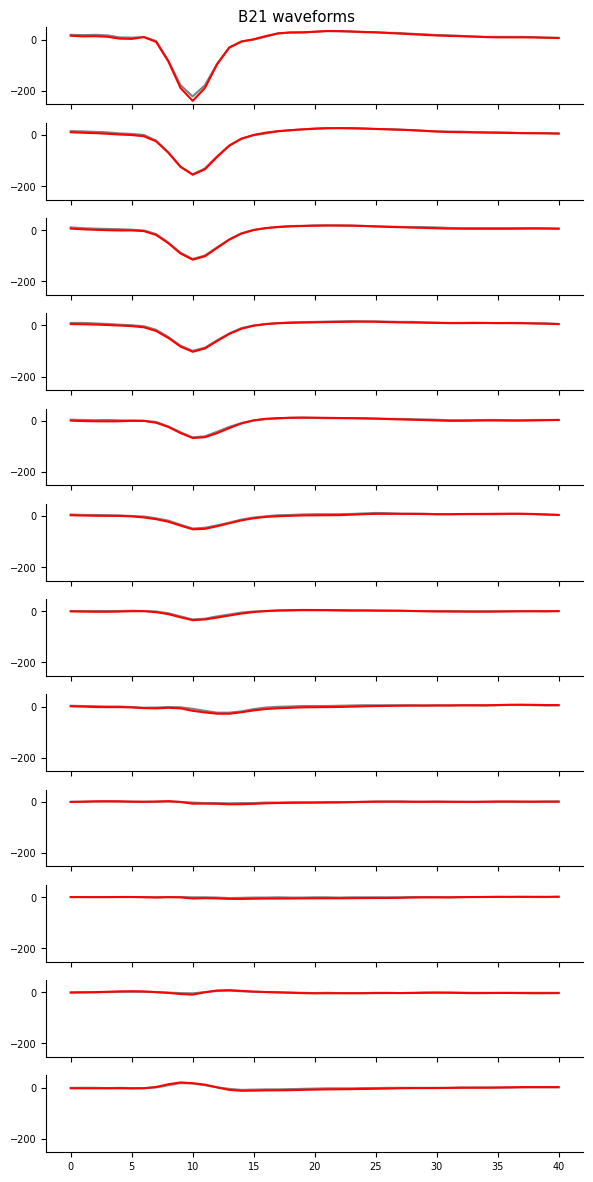

In [179]:
# compare cluster 21, 42, 43, 44

# cluster 21: 
#   - has 47 unique spike(s). 8531 of 8578 exist in the linear clusters. 
# first check if the cluster is valid based on the metrics from earlier and then see where these spikes are in the linear clusters. 
    
# mean firing rate of 2.260748 Hz
# ISI violation rate of 0.006063
# presence ratio of 1.00 

# check the mean waveoforms 
B21_waveforms = res_b[:,:,(bundled_spike_clusters == 21).squeeze()] # unit 21 = index 20 ; (41, 12, 8578)

fig, axes = plt.subplots(12, 1, figsize=(6, 12), sharex=True, sharey=True)

mean_b =  np.mean(B21_waveforms, axis=2) # shape 41, 12 
median_b = np.median(B21_waveforms, axis=2)

for i in range(12):   
    axes[i].plot(np.arange(41), median_b[:,i], color="gray")
    axes[i].plot(np.arange(41), mean_b[:, i], color="red")

plt.suptitle("B21 waveforms")
plt.tight_layout()
plt.show()

# compare how much each spike correlates with the mean or median waveform 


# filter out those that don't and see where these come from 

# make a bar plot of where the spike peak channels are ? 
# make a scatter plot linear cluster id vs peak channel to see where all the spikes fall (include no linear cluster is as a cateogry)


In [195]:
b_21_peak_chans = bundled_df_metrics[bundled_df_metrics["unit_id"] == 21]['peak_chan_idx'].iloc[0]
l_17_peak_chans = linear_df_metrics[linear_df_metrics["unit_id"] == 17]['peak_chan_idx'].iloc[0]

print(len(b_21_peak_chans), len(l_17_peak_chans))

for name, arr in [("bundled unit 21", b_21_peak_chans), ("linear unit 17", l_17_peak_chans)]:
    vals, counts = np.unique(arr, return_counts=True)
    print(f"\n{name}:")
    for v, c in zip(vals, counts):
        print(f"  chan {v}: {c} spikes; frac={c/len(arr)}")

8578 8985

bundled unit 21:
  chan 36: 8 spikes; frac=0.0009326183259501049
  chan 37: 4 spikes; frac=0.00046630916297505244
  chan 38: 9 spikes; frac=0.001049195616693868
  chan 39: 339 spikes; frac=0.039519701562135696
  chan 40: 143 spikes; frac=0.016670552576358126
  chan 41: 3657 spikes; frac=0.4263231522499417
  chan 42: 3749 spikes; frac=0.4370482629983679
  chan 43: 605 spikes; frac=0.07052926089997669
  chan 44: 37 spikes; frac=0.004313359757519235
  chan 46: 14 spikes; frac=0.0016320820704126837
  chan 47: 5 spikes; frac=0.0005828864537188156
  chan 48: 7 spikes; frac=0.0008160410352063418
  chan 49: 1 spikes; frac=0.00011657729074376311

linear unit 17:
  chan 36: 2 spikes; frac=0.00022259321090706732
  chan 37: 7 spikes; frac=0.0007790762381747357
  chan 38: 14 spikes; frac=0.0015581524763494713
  chan 39: 333 spikes; frac=0.03706176961602671
  chan 40: 137 spikes; frac=0.015247634947134112
  chan 41: 4136 spikes; frac=0.46032276015581525
  chan 42: 3829 spikes; frac=0.4261

In [201]:
# From your bundled siteLoc (0-indexed, shank 2 = sites 32-63)
bundled_siteLoc = np.array([...])  # your full 64x2 siteLoc array
ch41_b = siteLoc_bundled[41]
ch42_b = siteLoc_bundled[42]
ch41_l = siteLoc_linear[41]
ch42_l = siteLoc_linear[42]

dist_bundled = np.linalg.norm(ch41_b - ch42_b)
dist_linear  = np.linalg.norm(ch41_l - ch42_l)
print(f"Bundled: ch41-ch42 distance = {dist_bundled:.1f} μm")
print(f"Linear:  ch41-ch42 distance = {dist_linear:.1f} μm")

Bundled: ch41-ch42 distance = 32.8 μm
Linear:  ch41-ch42 distance = 19.5 μm


In [205]:
l_17_waveforms = res_l[:, :, :].T[linear_spike_clusters == 17] # 41 x 12 x spike num --> spikenum x 12 x 41 

IndexError: boolean index did not match indexed array along axis 0; size of axis is 722054 but size of corresponding boolean axis is 1

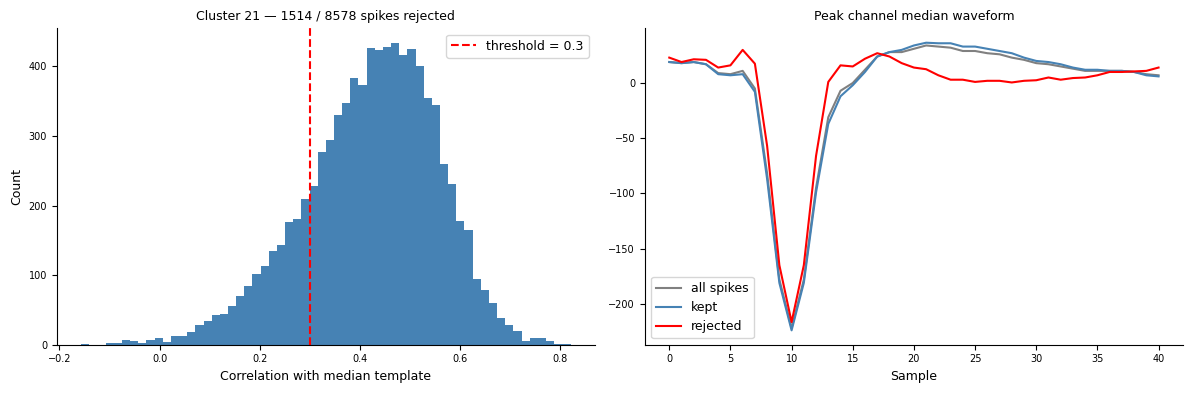

Kept:     7064 / 8578  (82.4%)
Rejected: 1514 / 8578  (17.6%)


In [180]:
def waveform_template_correlation(waveforms):
    """
    waveforms : (n_samples, n_chans, n_spikes)  — JRCLUST convention
    Returns per-spike Pearson correlation with the median template.
    """
    n_samples, n_chans, n_spikes = waveforms.shape

    # flatten to (n_spikes, n_samples * n_chans)
    wf = waveforms.transpose(2, 0, 1).reshape(n_spikes, -1).astype(np.float32)

    template = np.median(waveforms, axis=2).flatten().astype(np.float32)  # (n_samples * n_chans,) # TODO: mean or median 

    # centre each spike and the template
    wf_c = wf - wf.mean(axis=1, keepdims=True)
    t_c  = template - template.mean()

    # vectorised Pearson correlation
    num   = wf_c @ t_c                                    # (n_spikes,)
    denom = np.linalg.norm(wf_c, axis=1) * np.linalg.norm(t_c)
    corrs = num / np.where(denom == 0, 1, denom)          # guard div/0

    return corrs


def filter_by_correlation(waveforms, spike_times, spike_clusters_all,
                          cluster_id, threshold=0.5, plot=True):
    """
    waveforms          : (n_samples, n_chans, n_spikes) for this unit
    spike_times        : (n_spikes,) times for this unit
    spike_clusters_all : full spike cluster array (all spikes)
    cluster_id         : which cluster this is
    threshold          : minimum correlation to keep
    """
    corrs = waveform_template_correlation(waveforms)

    keep = corrs >= threshold
    reject = ~keep

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # correlation distribution
        axes[0].hist(corrs, bins=60, color="steelblue", edgecolor="none")
        axes[0].axvline(threshold, color="red", linestyle="--", label=f"threshold = {threshold}")
        axes[0].set_xlabel("Correlation with median template")
        axes[0].set_ylabel("Count")
        axes[0].set_title(f"Cluster {cluster_id} — {reject.sum()} / {len(corrs)} spikes rejected")
        axes[0].legend()

        # mean waveform before vs after on peak channel
        t = np.arange(waveforms.shape[0])
        axes[1].plot(t, np.median(waveforms[:, 0, :],        axis=1), label="all spikes",      color="gray")
        axes[1].plot(t, np.median(waveforms[:, 0, :][:,keep],axis=1), label="kept",             color="steelblue")
        if reject.any():
            axes[1].plot(t, np.median(waveforms[:, 0, :][:,reject],axis=1), label="rejected", color="red")
        axes[1].set_xlabel("Sample")
        axes[1].set_title("Peak channel median waveform")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    print(f"Kept:     {keep.sum()} / {len(corrs)}  ({keep.mean()*100:.1f}%)")
    print(f"Rejected: {reject.sum()} / {len(corrs)}  ({reject.mean()*100:.1f}%)")

    return corrs, keep


# ── usage ──────────────────────────────────────────────────────────────────

mask_21 = (bundled_spike_clusters == 21).squeeze()
B21_waveforms = res_b[:, :, mask_21]          # (41, 12, n_spikes)
B21_times     = b_spike_sampleAndChan[mask_21, 0]

corrs, keep = filter_by_correlation(
    B21_waveforms,
    B21_times,
    bundled_spike_clusters,
    cluster_id=21,
    threshold=0.3,
)

In [ ]:

# compute once
matches = identical_spikes(b_times, l_times, tol=0)

# then call cheaply per unit
fig, axes, data = plot_bundled_unit_linear_assignment(
    bundled_res_mat_path, linear_res_mat_path,
    bundled_unit_id=21,
    precomputed_matches=matches,
)
plt.show()

***

# Individual unit analysis

- ISI violation rate
- Isolation distance
- L-ratio
- Presence ratio
- Firing rate
- PCA ? 
- amplitude cutoff 
- D-prime
- nearest neighbor hit rate  

In [5]:
from sklearn.decomposition import PCA 

# collect all peak channel waveforms from both sortings 
b_data = loadmat(bundled_spikesFilt_path)
res_b = b_data['res']['spikesFilt'][0,0]
b_waveforms = res_b[:, 0, :].T # 41 x 12 x spike num --> spikenum x 41 

# all the linear spikes (sample and peak chan are found with bundled so we will not include them in PCA to avoid overlap)
l_data = loadmat(linear_spikesFilt_path)
res_l = l_data['res']['spikesFilt'][0,0]
l_waveforms = res_l[:, 0, :].T # 41 x 12 x spike num --> spikenum x 41 
#pool = np.concatenate((b_waveforms, l_waveforms), axis=0) # total spikenum x 41

# fit PCA 
pca = PCA(n_components = 12)
pca.fit(b_waveforms)

# use as pca.transform later on each unit to get the pca features 

,n_components,12
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [6]:
# bundled clusters 
bundled_unit_spike_times = {}
bundled_unit_pc_features = {}
bundled_unit_amps = {}
bundled_waveforms = {}
bundled_chan_indicies = {}


with h5py.File(Path(bundled_res_mat_path), "r") as f:
    spike_samples = f["spikeTimes"][...].squeeze() - 1
    spike_clusters = f["spikeClusters"][...].squeeze().astype("int32")
    b_spike_amps = f["spikeAmps"][...].squeeze()
    b_spike_sites    = f["spikeSites"][...].squeeze().ravel().astype("int32") - 1 

    for clus_id in np.unique(spike_clusters):
        bundled_unit_spike_times[clus_id] = spike_samples[spike_clusters == clus_id]
        bundled_unit_amps[clus_id] = b_spike_amps[spike_clusters == clus_id]
        bundled_chan_indicies[clus_id] = b_spike_sites[spike_clusters == clus_id]

        # get data from the b_waveforms 
        bundled_unit_waveforms = b_waveforms[spike_clusters == clus_id] 
        bundled_waveforms[clus_id] = bundled_unit_waveforms
        bundled_unit_pc_features[clus_id] = pca.transform(bundled_unit_waveforms)

# linear clusters 
linear_unit_spike_times = {}
linear_unit_pc_features = {}
linear_unit_amps = {}
linear_waveforms = {}
linear_chan_indicies = {}

with h5py.File(Path(linear_res_mat_path), "r") as f:
    spike_samples = f["spikeTimes"][...].squeeze() - 1
    spike_clusters = f["spikeClusters"][...].squeeze().astype("int32")
    l_spike_amps = f["spikeAmps"][...].squeeze()
    l_spike_sites    = f["spikeSites"][...].squeeze().ravel().astype("int32") - 1 

    
    for clus_id in np.unique(spike_clusters):
        linear_unit_spike_times[clus_id] = spike_samples[spike_clusters == clus_id]
        linear_unit_amps[clus_id] = l_spike_amps[spike_clusters == clus_id]
        linear_chan_indicies[clus_id] = l_spike_sites[spike_clusters == clus_id]
        
        # get data from the b_waveforms 
        linear_unit_waveforms = l_waveforms[spike_clusters == clus_id] 
        linear_waveforms[clus_id] = linear_unit_waveforms
        linear_unit_pc_features[clus_id] = pca.transform(linear_unit_waveforms)

In [8]:
# bundled metrics table
from cluster_analysis import compute_unit_metrics

bundled_df_metrics = compute_unit_metrics(bundled_unit_spike_times, bundled_unit_pc_features, bundled_chan_indicies, bundled_unit_amps, bundled_waveforms, 3794.32, "JRCLUST", "bundled", savefigs=False)

linear_df_metrics = compute_unit_metrics(linear_unit_spike_times, linear_unit_pc_features, linear_chan_indicies, linear_unit_amps, linear_waveforms, 3794.32, "JRCLUST", "linear", savefigs=False)

bundled_df_metrics

,sorter,probe_geometry,unit_id,peak_chan_idx,n_spikes,mean_spike_amp,firing_rate_hz,presence_ratio,waveform_similarity,isi_violation_rate,isolation_distance,l_ratio,d_prime,nn_hit_rate
0,JRCLUST,bundled,1,"[34, 32, 36, 35, 33, 32, 32, 34, 38, 34, 36, 3...",10365,-181.882586,2.731715,1.00,0.063386,0.033674,3.058130,21.025353,1.386219,0.808123
1,JRCLUST,bundled,2,"[32, 32, 34, 32, 32, 34, 32, 34, 32, 35, 32, 3...",3512,-161.995159,0.925594,1.00,0.061219,0.017374,2.826981,32.876981,1.725507,0.874431
2,JRCLUST,bundled,3,"[33, 33, 40, 33, 33, 33, 33, 33, 33, 33, 33, 3...",393,-170.310433,0.103576,0.90,0.091603,0.010204,2.350850,129.645164,1.798587,0.867684
3,JRCLUST,bundled,4,"[33, 33, 33, 33, 33, 39, 33, 43, 33, 35, 35, 3...",1023,-178.482893,0.269614,1.00,0.080156,0.010763,2.308843,93.647124,1.562882,0.843402
4,JRCLUST,bundled,5,"[33, 33, 33, 34, 33, 39, 34, 33, 33, 34, 33, 3...",111,-187.594595,0.029254,0.53,0.063063,0.018182,1.288437,930.901974,1.503178,0.819820
5,JRCLUST,bundled,6,"[33, 33, 33, 33, 33, 33, 33, 33, 39, 39, 33, 3...",127,-225.960630,0.033471,0.73,0.031496,0.015873,0.785813,2481.016663,1.118930,0.762205
6,JRCLUST,bundled,7,"[34, 34, 34, 34, 34, 32, 39, 41, 34, 34, 34, 3...",7048,-160.834989,1.857513,1.00,0.049801,0.016319,3.643828,16.375617,1.761772,0.869580
7,JRCLUST,bundled,8,"[35, 36, 35, 35, 35, 35, 33, 35, 35, 35, 35, 3...",4812,-204.907315,1.268211,1.00,0.283458,0.005612,3.695277,26.794976,1.290819,0.804447
8,JRCLUST,bundled,9,"[35, 35, 35, 38, 35, 35, 35, 35, 35, 35, 35, 3...",322,-199.773292,0.084864,0.55,0.260870,0.006231,2.646127,209.881097,1.334660,0.847826
9,JRCLUST,bundled,10,"[36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 36, 3...",204,-274.897059,0.053765,0.42,0.916667,0.004926,9.330250,14.307036,4.379862,0.947059


In [9]:
bundled_df_metrics.to_csv("/Volumes/Trenholm2/neuroTechData/jun16_data/bundled_metrics.csv", index=True)
linear_df_metrics.to_csv("/Volumes/Trenholm2/neuroTechData/jun16_data/linear_metrics.csv", index=True)

## Figure 2 

In [12]:
siteLoc_bundled[:32, 1]

array([732.        , 698.        , 678.        , 645.        ,
       625.        , 593.        , 573.        , 542.        ,
       522.        , 491.        , 472.        , 442.        ,
       422.        , 393.        , 374.        , 346.        ,
       326.        , 299.        , 280.        , 253.        ,
       234.        , 209.        , 189.        , 165.        ,
       145.        , 122.        , 102.        ,  80.22594789,
        60.72594789,  39.56206844,  20.06206844,   0.        ])

In [11]:
siteLoc_linear[:32, 1]

array([604.5, 585. , 565.5, 546. , 526.5, 507. , 487.5, 468. , 448.5,
       429. , 409.5, 390. , 370.5, 351. , 331.5, 312. , 292.5, 273. ,
       253.5, 234. , 214.5, 195. , 175.5, 156. , 136.5, 117. ,  97.5,
        78. ,  58.5,  39. ,  19.5,   0. ])

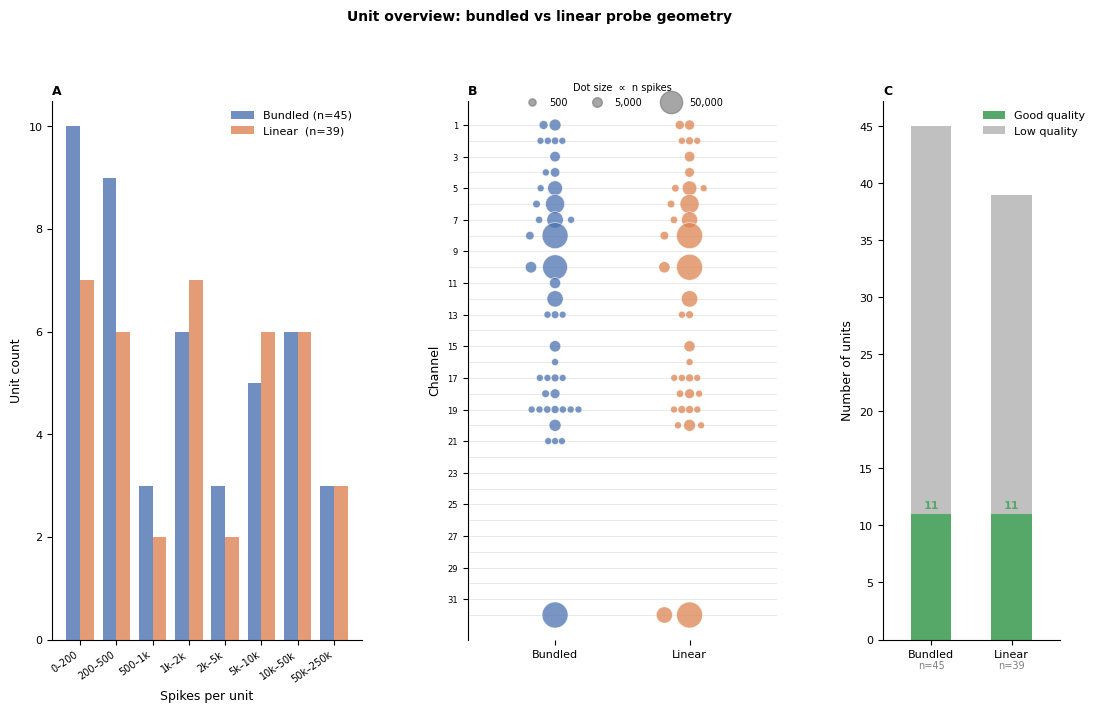

Saved: cluster_overview.pdf / .png


In [56]:
"""
Cluster overview comparison: bundled vs linear geometry.

Panels:
  A (left)   — Spike count histogram per unit (both geometries)
  B (middle) — Channel strip plot (channel vs unit, size ∝ n_spikes)
  C (right)  — Good vs low-quality unit breakdown (stacked bar)

Requires:
  bundled_df_metrics, linear_df_metrics  — from compute_unit_metrics()
  Column 'peak_chan_idx' must be present (array of per-spike site indices).
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
from matplotlib.patches import Patch
from scipy.stats import mode as scipy_mode

# ── Shared style ──────────────────────────────────────────────────────────────
COL_B    = '#4C72B0'
COL_L    = '#DD8452'
FS_LABEL = 9
FS_TICK  = 8

plt.rcParams.update({
    'font.size':         FS_LABEL,
    'axes.titlesize':    FS_LABEL,
    'axes.labelsize':    FS_LABEL,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Quality labelling (Allen Brain / IBL thresholds) ─────────────────────────
def label_good_units(df):
    df = df.copy()
    df['is_good'] = (
        (df['isi_violation_rate'] <  0.05) &
        (df['presence_ratio']     >= 0.90) &
        (df['d_prime']            >  1.00) &
        (df['nn_hit_rate']        >= 0.80)
    )
    return df

# ── Derive scalar peak channel per unit ──────────────────────────────────────
def modal_chan(df):
    return df['peak_chan_idx'].apply(
        lambda x: int(scipy_mode(np.asarray(x).ravel(), keepdims=False).mode)
    )

bundled_df = bundled_df_metrics.copy()
linear_df  = linear_df_metrics.copy()

bundled_df['peak_chan'] = modal_chan(bundled_df)
linear_df['peak_chan']  = modal_chan(linear_df)

# ── Layout: 1 row, 2 columns ─────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 7))
gs  = gridspec.GridSpec(
    1, 3,
    figure       = fig,
    width_ratios = [1.4, 1.4, 0.8],
    wspace       = 0.40,
)

ax_a = fig.add_subplot(gs[0, 0])   # Panel A: spike count histogram
ax_b = fig.add_subplot(gs[0, 1])   # Panel B: channel strip plot
ax_c = fig.add_subplot(gs[0, 2])   # Panel C: good vs bad stacked bar

# ── Panel A: Histogram of spike counts per unit ───────────────────────────────
BINS = [0, 200, 500, 1_000, 2_000, 5_000, 10_000, 50_000, 250_000]

def fmt_bin(lo, hi):
    def fmt(n):
        if n == 0:     return '0'
        if n >= 1_000: return f'{n // 1_000}k'
        return str(n)
    return f'{fmt(lo)}–{fmt(hi)}'

bin_labels = [fmt_bin(BINS[i], BINS[i+1]) for i in range(len(BINS) - 1)]
x_pos = np.arange(len(bin_labels))
bar_w = 0.38

b_counts = np.histogram(bundled_df['n_spikes'], bins=BINS)[0]
l_counts = np.histogram(linear_df['n_spikes'],  bins=BINS)[0]

ax_a.bar(x_pos - bar_w / 2, b_counts, width=bar_w,
         color=COL_B, alpha=0.80, label=f'Bundled (n={len(bundled_df)})')
ax_a.bar(x_pos + bar_w / 2, l_counts, width=bar_w,
         color=COL_L, alpha=0.80, label=f'Linear  (n={len(linear_df)})')

ax_a.set_xticks(x_pos)
ax_a.set_xticklabels(bin_labels, rotation=35, ha='right', fontsize=7)
ax_a.set_xlabel('Spikes per unit')
ax_a.set_ylabel('Unit count')
ax_a.set_title('A', loc='left', fontweight='bold', pad=4)
ax_a.legend(fontsize=FS_TICK, frameon=False)
ax_a.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# ── Panel B: Channel strip plot ───────────────────────────────────────────────

# Horizontal guide lines at each active channel position
active_chans = list(range(32, 64))
for ch in active_chans:
    ax_b.axhline(ch, color='#e0e0e0', lw=0.5, zorder=0)

# Scale dot area proportional to n_spikes
all_n  = np.concatenate([bundled_df['n_spikes'].values,
                         linear_df['n_spikes'].values])
s_min, s_max = 25, 350
n_min, n_max = all_n.min(), np.percentile(all_n, 95)

def n_to_size(n):
    clipped = np.clip(n, n_min, n_max)
    return s_min + (s_max - s_min) * (clipped - n_min) / (n_max - n_min)

def center_out_x(n_spikes_series, strip_center, base_step=0.05):
    """
    Largest unit at strip_center, smaller units alternating outward.
    Step scales with visual dot size to prevent overlap.
    """
    ranks = (n_spikes_series.rank(ascending=False, method='first')
             .astype(int) - 1)
    max_dot_area = n_to_size(n_spikes_series.max())
    step = base_step * np.sqrt(max_dot_area / s_min)

    def offset(r):
        if r == 0: return 0.0
        sign      = -1 if r % 2 == 1 else 1
        magnitude = (r + 1) // 2
        return sign * magnitude * step

    return strip_center + ranks.map(offset)

# Assign x positions per channel group
bundled_df = bundled_df.copy()
linear_df  = linear_df.copy()

bundled_df['strip_x'] = np.nan
linear_df['strip_x']  = np.nan

for chan, grp in bundled_df.groupby('peak_chan'):
    bundled_df.loc[grp.index, 'strip_x'] = center_out_x(grp['n_spikes'],
                                                          strip_center=0.0)
for chan, grp in linear_df.groupby('peak_chan'):
    linear_df.loc[grp.index, 'strip_x']  = center_out_x(grp['n_spikes'],
                                                          strip_center=1.0)

ax_b.scatter(bundled_df['strip_x'], bundled_df['peak_chan'],
             s=n_to_size(bundled_df['n_spikes'].values),
             color=COL_B, alpha=0.75, edgecolors='white', lw=0.5,
             label='Bundled', zorder=2)
ax_b.scatter(linear_df['strip_x'], linear_df['peak_chan'],
             s=n_to_size(linear_df['n_spikes'].values),
             color=COL_L, alpha=0.75, edgecolors='white', lw=0.5,
             label='Linear', zorder=2)

# Channel 32 = probe top, channel 63 = probe tip → invert so 32 is at top
ax_b.invert_yaxis()
ax_b.set_yticks(active_chans[::2])          # every other channel to avoid crowding
ax_b.set_yticklabels(np.array(active_chans[::2]) -31, fontsize=6)
ax_b.set_ylabel('Channel')
ax_b.set_xticks([0, 1])
ax_b.set_xticklabels(['Bundled', 'Linear'], fontsize=FS_TICK)
ax_b.set_xlim(-0.65, 1.65)
ax_b.set_title('B', loc='left', fontweight='bold', pad=4)
ax_b.spines['bottom'].set_visible(False)

# Size legend
size_vals  = [500, 5_000, 50_000]
size_dots  = [mlines.Line2D([], [], color='grey', marker='o', ls='',
                             ms=np.sqrt(n_to_size(v)), alpha=0.7,
                             label=f'{v:,}')
              for v in size_vals]
ax_b.legend(handles=size_dots, fontsize=7, frameon=False,
            loc='upper center', ncol=len(size_vals),
            title='Dot size  ∝  n spikes', title_fontsize=7,
            bbox_to_anchor=(0.5, 1.05))

# ── Panel C: Good vs low-quality unit breakdown ───────────────────────────────
COL_GOOD = '#55A868'   # green
COL_BAD  = '#C0C0C0'   # grey

bundled_labeled = label_good_units(bundled_df)
linear_labeled  = label_good_units(linear_df)

b_good = int(bundled_labeled['is_good'].sum())
b_bad  = int((~bundled_labeled['is_good']).sum())
l_good = int(linear_labeled['is_good'].sum())
l_bad  = int((~linear_labeled['is_good']).sum())

x     = np.array([0, 1])
bar_w = 0.50

ax_c.bar(x, [b_good, l_good], width=bar_w, color=COL_GOOD,
         label='Good quality')
ax_c.bar(x, [b_bad,  l_bad],  width=bar_w, color=COL_BAD,
         bottom=[b_good, l_good], label='Low quality')

# Annotate good count at the top of the green section
for xi, good in zip(x, [b_good, l_good]):
    ax_c.text(xi, good + 0.3, f'{good}',
              ha='center', va='bottom', fontsize=8,
              fontweight='bold', color=COL_GOOD)

# Annotate total below x-axis
for xi, total in zip(x, [len(bundled_labeled), len(linear_labeled)]):
    ax_c.text(xi, -1.8, f'n={total}',
              ha='center', va='top', fontsize=7, color='grey')

ax_c.set_xticks(x)
ax_c.set_xticklabels(['Bundled', 'Linear'], fontsize=FS_TICK)
ax_c.set_xlim(-0.6, 1.6)
ax_c.set_ylabel('Number of units')
ax_c.set_title('C', loc='left', fontweight='bold', pad=4)
ax_c.legend(fontsize=FS_TICK, frameon=False, loc='upper right', bbox_to_anchor=(1.2, 1.00))
ax_c.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# ── Supertitle ────────────────────────────────────────────────────────────────
fig.suptitle('Unit overview: bundled vs linear probe geometry',
             fontsize=10, fontweight='bold', y=1.01)

plt.savefig('cluster_overview.pdf', bbox_inches='tight', dpi=300)
plt.savefig('cluster_overview.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: cluster_overview.pdf / .png")

In [18]:
print("---Bundled---")
print(bundled_df['n_spikes'].describe())

print("---Linear---")
print(linear_df['n_spikes'].describe())

---Bundled---
count        45.000000
mean      16137.888889
std       49334.132557
min          90.000000
25%         205.000000
50%        1023.000000
75%        8578.000000
max      242544.000000
Name: n_spikes, dtype: float64
---Linear---
count        39.000000
mean      18514.205128
std       50701.591561
min          95.000000
25%         273.500000
50%        1700.000000
75%        8738.000000
max      245200.000000
Name: n_spikes, dtype: float64


In [74]:
# as defined by allen brain / IBL standards 
def label_good_units(df):
    df = df.copy()
    df["is_good"] = (
        (df["isi_violation_rate"]   < 0.05)  &   # < 5% refractory violations
        (df["presence_ratio"]       >= 0.90)  & #&   # present for 90%+ of recording
        (df["d_prime"]   > 1.0)    &                # minimal overlap with noise
        (df["nn_hit_rate"]          >= 0.80)       # 80%+ neighbours are same unit
    )
    return df

def group_summary(df):
    summary = (
        df.groupby(["probe_geometry", "is_good"])
        .agg(
            n_units        = ("unit_id",            "count"),
            mean_spike_num        = ("n_spikes",            "mean"),
            median_Hz      = ("firing_rate_hz",      "median"),
            median_presence_ratio      = ("presence_ratio",      "median"),
            median_isi     = ("isi_violation_rate",  "median"),
            mean_spike_amp       = ("mean_spike_amp",       "mean"),
            mean_waveform_sim = ("waveform_similarity", "mean"), 
            #median_iso     = ("isolation_distance",  "median"),
            #median_lratio  = ("l_ratio",             "median"),
            #median_dprime  = ("d_prime",             "median"),
            #median_nn      = ("nn_hit_rate",         "median"),
        )
        .round(5)
    )
    return summary

bundled_df_metrics_labeled = label_good_units(bundled_df_metrics)
print(group_summary(bundled_df_metrics_labeled))

linear_df_metrics_labeled = label_good_units(linear_df_metrics)
print(group_summary(linear_df_metrics_labeled))

                        n_units  mean_spike_num  median_Hz  \
probe_geometry is_good                                       
bundled        False         34     20108.85294    0.10463   
               True          11      3864.00000    0.71844   

                        median_presence_ratio  median_isi  mean_spike_amp  \
probe_geometry is_good                                                      
bundled        False                     0.88     0.00479      -248.55344   
               True                      1.00     0.01020      -278.79731   

                        mean_waveform_sim  
probe_geometry is_good                     
bundled        False              0.23736  
               True               0.27540  
                        n_units  mean_spike_num  median_Hz  \
probe_geometry is_good                                       
linear         False         28     24406.78571    0.41641   
               True          11      3514.90909    0.76535   

                 

In [ ]:
linear_df_metrics_labeled["unit_id"][linear_df_metrics_labeled["is_good"] == True] # units 1, 2, 3, 6, 7, 10, 11, 13, 16, 22, 26 
bundled_df_metrics_labeled[:][bundled_df_metrics_labeled["is_good"] == True] # units 1, 2, 3, 4, 7, 8, 13, 15, 18, 26, 29


0     [32, 38, 32, 34, 32, 39, 38, 32, 34, 37, 32, 3...
1     [32, 32, 34, 34, 32, 32, 35, 32, 34, 34, 32, 3...
2     [33, 33, 33, 33, 33, 33, 33, 33, 35, 33, 33, 3...
5     [34, 34, 36, 34, 34, 33, 34, 32, 41, 36, 34, 3...
6     [35, 35, 35, 35, 35, 35, 35, 35, 32, 35, 35, 3...
9     [36, 38, 38, 36, 36, 36, 38, 36, 39, 36, 38, 3...
10    [39, 39, 37, 37, 37, 37, 37, 37, 37, 39, 37, 3...
12    [38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 38, 3...
15    [39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 3...
21    [47, 46, 46, 46, 46, 46, 47, 46, 47, 48, 41, 4...
25    [46, 46, 46, 46, 46, 43, 46, 46, 46, 46, 46, 4...
Name: peak_chan_idx, dtype: object

***

## cluster analysis

In [ ]:
sc_clusters = []
cluster_sites = []

for res_p in [bundled_res_mat_path, linear_res_mat_path]:
    res_file = Path(res_p)

    with h5py.File(res_file, "r") as f:
        sc = f["spikeClusters"][...].squeeze().ravel().astype(np.int32) # ignore sites with index -1 and 0 ? 
        sc_clusters.append(sc)

        cs = f["clusterSites"][...].squeeze().ravel().astype("int32") # index !! 
        cluster_sites.append(cs)

In [175]:
import numpy as np
import pandas as pd

def compare_cluster_assignments(
    clusters_A,
    clusters_B,
    matches_spikeTime_andChan,
    n_spikes_A=None,
    n_spikes_B=None,
    name_A="bundled",
    name_B="linear",
):
    clusters_A = np.asarray(clusters_A)
    clusters_B = np.asarray(clusters_B)
    matches = np.asarray(matches_spikeTime_andChan, dtype=int)

    if n_spikes_A is None:
        n_spikes_A = len(clusters_A)
    if n_spikes_B is None:
        n_spikes_B = len(clusters_B)

    idx_A = matches[:, 0]
    idx_B = matches[:, 1]

    matched_clusters_A = clusters_A[idx_A]
    matched_clusters_B = clusters_B[idx_B]


    # matched spike-level table
    matched_df = pd.DataFrame({
        f"{name_A}_spike_idx": idx_A,
        f"{name_B}_spike_idx": idx_B,
        f"{name_A}_cluster": matched_clusters_A,
        f"{name_B}_cluster": matched_clusters_B,
    })
    
    # -----------------------------
    # 2. Cluster overlap table # counts how many matched spikes fall into each (A cluster, B cluster) pair
    # -----------------------------
    overlap = (
        matched_df
        .groupby([f"{name_A}_cluster", f"{name_B}_cluster"])
        .size()
        .reset_index(name="n_shared_spikes")
        .sort_values("n_shared_spikes", ascending=False)
        .reset_index(drop=True)
    )

    # total matched spikes per cluster
    total_A = matched_df[f"{name_A}_cluster"].value_counts()
    total_B = matched_df[f"{name_B}_cluster"].value_counts()

    overlap[f"{name_A}_matched_total"] = overlap[f"{name_A}_cluster"].map(total_A)
    overlap[f"{name_B}_matched_total"] = overlap[f"{name_B}_cluster"].map(total_B)

    overlap[f"frac_of_{name_A}"] = (
        overlap["n_shared_spikes"] / overlap[f"{name_A}_matched_total"]
    )
    overlap[f"frac_of_{name_B}"] = (overlap["n_shared_spikes"] / overlap[f"{name_B}_matched_total"])

    overlap['match_score'] = np.sqrt(overlap['frac_of_bundled'] * overlap['frac_of_linear'])

    # -----------------------------
    # 3. Best cluster mapping
    #    A -> B by maximum shared spikes. ie for each A cluster, pick the B cluster with the largest overlap 
    # many A clusters can map to the same B cluster (good for detecting merges)
    # -----------------------------
    best_A_to_B = (
        overlap
        .sort_values("n_shared_spikes", ascending=False)
        .drop_duplicates(f"{name_A}_cluster")
        .reset_index(drop=True)
    )

    best_A_to_B_frac = (
        overlap
        .sort_values("match_score", ascending=False)
        .drop_duplicates(f"{name_A}_cluster")
        .reset_index(drop=True)
    )

    A_to_B = dict(zip(
        best_A_to_B[f"{name_A}_cluster"],
        best_A_to_B[f"{name_B}_cluster"],
    ))

    # also B -> A, useful for checking merges/splits
    best_B_to_A = (
        overlap
        .sort_values("n_shared_spikes", ascending=False)
        .drop_duplicates(f"{name_B}_cluster")
        .reset_index(drop=True)
    )
    best_B_to_A_frac = (
        overlap
        .sort_values("match_score", ascending=False)
        .drop_duplicates(f"{name_B}_cluster")
        .reset_index(drop=True)
    )

    B_to_A = dict(zip(
        best_B_to_A[f"{name_B}_cluster"],
        best_B_to_A[f"{name_A}_cluster"],
    ))

    # -----------------------------
    # 4. Classify matched spikes
    # -----------------------------
    expected_B = np.array([A_to_B[a] for a in matched_clusters_A])

    matched_df[f"expected_{name_B}_cluster"] = expected_B
    matched_df["same_mapped_unit"] = matched_clusters_B == expected_B

    reassigned_matched = matched_df[~matched_df["same_mapped_unit"]]

    reassigned_summary = (
        reassigned_matched
        .groupby([
            f"{name_A}_cluster",
            f"expected_{name_B}_cluster",
            f"{name_B}_cluster",
        ])
        .size()
        .reset_index(name="n_reassigned_matched_spikes")
        .sort_values("n_reassigned_matched_spikes", ascending=False)
        .reset_index(drop=True)
    )

    # -----------------------------
    # 5. Unmatched spikes in A and B
    # -----------------------------
    unmatched_A_mask = np.ones(len(clusters_A), dtype=bool)
    unmatched_B_mask = np.ones(len(clusters_B), dtype=bool)

    unmatched_A_mask[idx_A] = False
    unmatched_B_mask[idx_B] = False

    unmatched_A_clusters = clusters_A[unmatched_A_mask]
    unmatched_B_clusters = clusters_B[unmatched_B_mask]

    unmatched_A_counts = (
        pd.Series(unmatched_A_clusters)
        .value_counts()
        .rename_axis(f"{name_A}_cluster")
        .reset_index(name=f"n_unmatched_{name_A}_spikes")
    )

    unmatched_B_counts = (
        pd.Series(unmatched_B_clusters)
        .value_counts()
        .rename_axis(f"{name_B}_cluster")
        .reset_index(name=f"n_unmatched_{name_B}_spikes")
    )

    # Attach expected partner cluster to unmatched A spikes
    unmatched_A_counts[f"mapped_{name_B}_cluster"] = (
        unmatched_A_counts[f"{name_A}_cluster"].map(A_to_B)
    )

    # -----------------------------
    # 6. Split / merge diagnostics
    # -----------------------------
    n_B_per_A = (
        overlap
        .groupby(f"{name_A}_cluster")[f"{name_B}_cluster"]
        .nunique()
        .reset_index(name=f"n_{name_B}_clusters_receiving_spikes")
    )

    n_A_per_B = (
        overlap
        .groupby(f"{name_B}_cluster")[f"{name_A}_cluster"]
        .nunique()
        .reset_index(name=f"n_{name_A}_clusters_contributing_spikes")
    )

    summary = {
        "n_matched_spikes": len(matches),
        f"n_unmatched_{name_A}_spikes": int(unmatched_A_mask.sum()),
        f"n_unmatched_{name_B}_spikes": int(unmatched_B_mask.sum()),
        "n_same_mapped_unit": int(matched_df["same_mapped_unit"].sum()),
        "frac_same_mapped_unit": float(matched_df["same_mapped_unit"].mean()),
        "n_reassigned_matched_spikes": int((~matched_df["same_mapped_unit"]).sum()),
        "frac_reassigned_matched_spikes": float((~matched_df["same_mapped_unit"]).mean()),
    }

    return {
        "summary": summary,
        "matched_spikes": matched_df,
        "overlap": overlap,
        "best_A_to_B": best_A_to_B,
        "best_A_to_B_frac": best_A_to_B_frac,
        "best_B_to_A": best_B_to_A,
        "best_B_to_A_frac": best_B_to_A_frac,
        "reassigned_matched": reassigned_summary,
        f"unmatched_{name_A}_counts": unmatched_A_counts,
        f"unmatched_{name_B}_counts": unmatched_B_counts,
        "split_diagnostics": n_B_per_A,
        "merge_diagnostics": n_A_per_B,
        f"unmatched_{name_A}_mask": unmatched_A_mask,
        f"unmatched_{name_B}_mask": unmatched_B_mask,
    }

res = compare_cluster_assignments(
    clusters_A=sc_clusters[0],
    clusters_B=sc_clusters[1],
    matches_spikeTime_andChan=matches_spikeTime_andChan,
    name_A="bundled",
    name_B="linear")


#res["best_B_to_A"] # shows the best cluster matches with repeats in B and not A 
#res['reassigned_matched'].head(20) # Shows matched spikes that belong to a bundled cluster but were assigned to a non-equivalent linear cluster
#res["unmatched_bundled_counts"] # shows which bundled clusters contain extra bundled-only spikes
#res["summary"]["frac_same_mapped_unit"] # of spikes that matched in time, what fraction were assigned to the corresponding unit across time

res["summary"]


{'n_matched_spikes': 722054,
 'n_unmatched_bundled_spikes': 4151,
 'n_unmatched_linear_spikes': 0,
 'n_same_mapped_unit': 622377,
 'frac_same_mapped_unit': 0.8619535381010285,
 'n_reassigned_matched_spikes': 99677,
 'frac_reassigned_matched_spikes': 0.13804646189897155}

In [174]:
res.keys()

key = "matched_spikes"
res[key].to_csv(f"/Volumes/Trenholm2/neuroTechData/jun16_data/{key}.csv", index=True)
key = "overlap"
res[key].to_csv(f"/Volumes/Trenholm2/neuroTechData/jun16_data/{key}.csv", index=True)
key = "best_A_to_B"
res[key].to_csv(f"/Volumes/Trenholm2/neuroTechData/jun16_data/{key}.csv", index=True)
key = "best_B_to_A"
res[key].to_csv(f"/Volumes/Trenholm2/neuroTechData/jun16_data/{key}.csv", index=True)
key = "reassigned_matched"
res[key].to_csv(f"/Volumes/Trenholm2/neuroTechData/jun16_data/{key}.csv", index=True)
key = "unmatched_bundled_counts"
res[key].to_csv(f"/Volumes/Trenholm2/neuroTechData/jun16_data/{key}.csv", index=True)
key = "unmatched_linear_counts"
res[key].to_csv(f"/Volumes/Trenholm2/neuroTechData/jun16_data/{key}.csv", index=True)
key = "split_diagnostics"
res[key].to_csv(f"/Volumes/Trenholm2/neuroTechData/jun16_data/{key}.csv", index=True)
key = "merge_diagnostics"
res[key].to_csv(f"/Volumes/Trenholm2/neuroTechData/jun16_data/{key}.csv", index=True)

In [178]:
best_AB = res["best_A_to_B"]   # bundled → best linear (by num_spikes)
best_BA = res["best_B_to_A"]   # linear  → best bundled (by num_spikes)

mutual_pairs = (
    best_AB[["bundled_cluster", "linear_cluster", "n_shared_spikes"]]
    .merge(
        best_BA[["linear_cluster", "bundled_cluster"]].rename(columns={"bundled_cluster": "bundled_back"}),
        on="linear_cluster",
    )
    .query("bundled_cluster == bundled_back")
    .drop(columns="bundled_back")
    .reset_index(drop=True)
)

print(mutual_pairs)

    bundled_cluster  linear_cluster  n_shared_spikes
0                17              15           227391
1                45              39           203898
2                20              18            53627
3                12              12            32189
4                22              19            21253
5                16              14            16258
6                11               9            13576
7                41              35             9013
8                26              22             7238
9                33              28             4228
10                7               6             4088
11               21              17             3846
12                8               7             3680
13                1               2             2609
14               18              16             2322
15               13              11             1194
16               35              32             1123
17               29              24           

In [177]:
best_AB = res["best_A_to_B_frac"]   # bundled → best linear (by match_score)
best_BA = res["best_B_to_A_frac"]   # linear  → best bundled (by match_score)

mutual_pairs = (
    best_AB[["bundled_cluster", "linear_cluster", "match_score"]]
    .merge(
        best_BA[["linear_cluster", "bundled_cluster"]].rename(columns={"bundled_cluster": "bundled_back"}),
        on="linear_cluster",
    )
    .query("bundled_cluster == bundled_back")
    .drop(columns="bundled_back")
    .reset_index(drop=True)
)

print(mutual_pairs)

    bundled_cluster  linear_cluster  match_score
0                45              39     0.940927
1                13              11     0.936471
2                17              15     0.932828
3                10               8     0.912702
4                12              12     0.908220
5                15              13     0.876986
6                22              19     0.865439
7                41              35     0.844900
8                26              22     0.830147
9                18              16     0.825279
10               20              18     0.797729
11               33              28     0.775829
12                8               7     0.762201
13               11               9     0.727438
14               16              14     0.667356
15                7               6     0.605249
16               35              32     0.582970
17               23              20     0.494807
18               29              24     0.485863
19               40 

In [152]:
res["best_A_to_B"]

,bundled_cluster,linear_cluster,n_shared_spikes,bundled_matched_total,linear_matched_total,frac_of_bundled,frac_of_linear
0,17,15,227391,242339,245200,0.938318,0.927369
1,45,39,203898,228984,205073,0.890446,0.994270
2,20,18,53627,63572,71087,0.843563,0.754385
3,12,12,32189,35539,35345,0.905737,0.910709
4,22,19,21253,24176,24945,0.879095,0.851994
5,16,14,16258,24939,23798,0.651911,0.683167
6,11,9,13576,18758,18568,0.723745,0.731150
7,41,35,9013,10768,10568,0.837017,0.852858
8,26,22,7238,8953,8491,0.808444,0.852432
9,19,18,6883,9353,71087,0.735914,0.096825


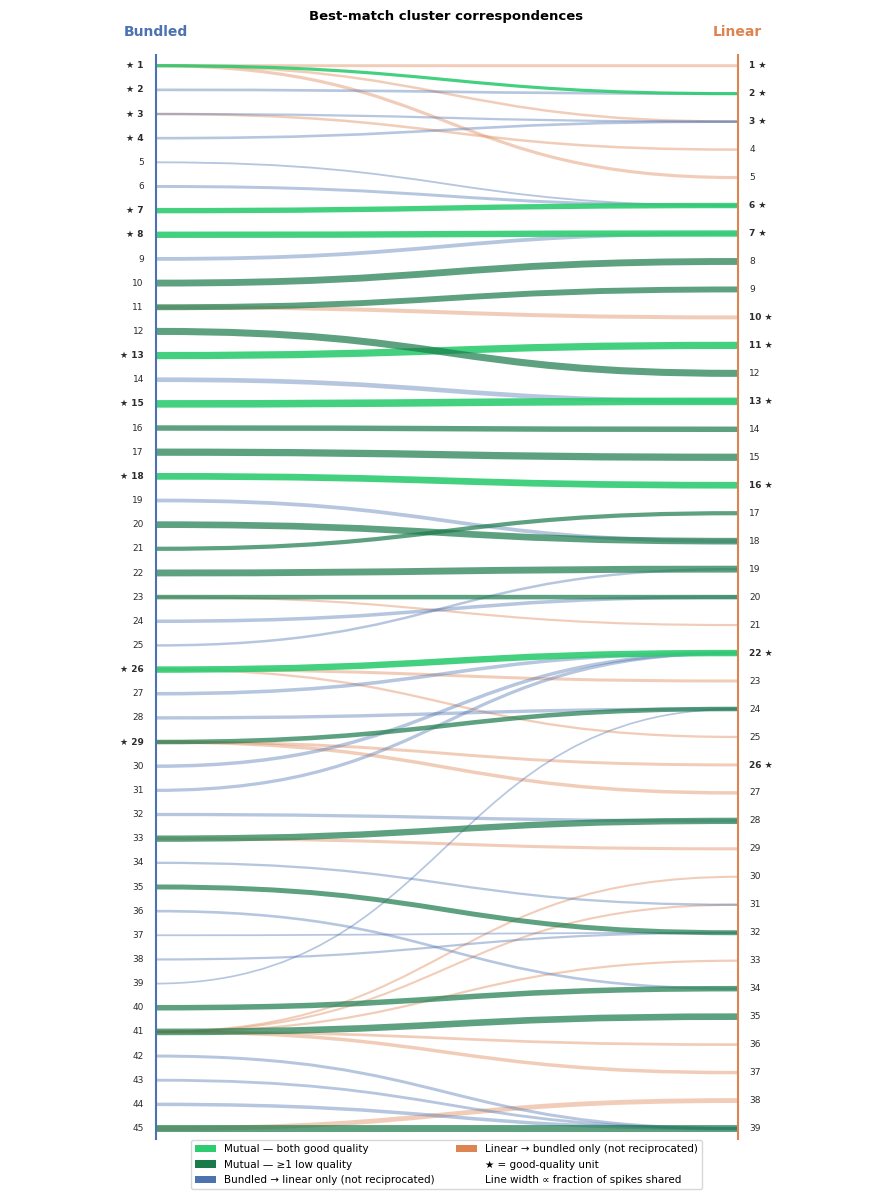

Saved: bipartite_matches.pdf / .png


In [156]:
"""
Bipartite graph: bundled ↔ linear cluster best matches.

Left  column = bundled clusters  (ordered by peak channel / probe depth)
Right column = linear clusters   (ordered by peak channel / probe depth)

Line types:
  Gold  thick   — mutual best-match AND good quality in both conditions
  Blue  medium  — mutual best-match, at least one low-quality
  Grey  thin    — one-directional (bundled → linear, but linear's best ≠ this bundled)

Line width ∝ frac_of_bundled (fraction of bundled cluster's spikes in this match).

Requires:
  res["best_A_to_B"], res["best_B_to_A"]
  bundled_df_metrics, linear_df_metrics  (with 'unit_id', 'peak_chan_idx', 'is_good')
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from scipy.stats import mode as scipy_mode

# ── Quality labels ────────────────────────────────────────────────────────────
def label_good_units(df):
    df = df.copy()
    df['is_good'] = (
        (df['isi_violation_rate'] <  0.05) &
        (df['presence_ratio']     >= 0.90) &
        (df['d_prime']            >  1.00) &
        (df['nn_hit_rate']        >= 0.80)
    )
    return df

bundled_df = label_good_units(bundled_df_metrics.copy())
linear_df  = label_good_units(linear_df_metrics.copy())

# ── Peak channel per unit (modal site) ───────────────────────────────────────
def modal_chan(df):
    return df['peak_chan_idx'].apply(
        lambda x: int(scipy_mode(np.asarray(x).ravel(), keepdims=False).mode)
    )

bundled_df['peak_chan'] = modal_chan(bundled_df)
linear_df['peak_chan']  = modal_chan(linear_df)

# ── Build match lookups ───────────────────────────────────────────────────────
best_AB = res["best_A_to_B"]   # bundled → best linear
best_BA = res["best_B_to_A"]   # linear  → best bundled

A_to_B  = dict(zip(best_AB['bundled_cluster'], best_AB['linear_cluster']))
B_to_A  = dict(zip(best_BA['linear_cluster'],  best_BA['bundled_cluster']))
frac_b  = dict(zip(best_AB['bundled_cluster'], best_AB['frac_of_bundled']))

# ── Y-positions: ordered by peak channel (higher channel = lower on plot) ─────
def rank_positions(df, col='unit_id'):
    """Map unit_id → y in [0,1], sorted by cluster ID: lowest ID at top (y=1)."""
    ordered = df.sort_values(col)['unit_id'].tolist()
    n = len(ordered)
    return {uid: 1.0 - i / (n - 1) for i, uid in enumerate(ordered)}

b_y  = rank_positions(bundled_df)
l_y  = rank_positions(linear_df)

b_good = set(bundled_df.loc[bundled_df['is_good'], 'unit_id'])
l_good = set(linear_df.loc[linear_df['is_good'],   'unit_id'])

# ── Colours ───────────────────────────────────────────────────────────────────
COL_GOOD_MUTUAL = '#2ECC71'   # bright green  — mutual + both good quality
COL_MUTUAL      = '#1A7A4A'   # dark green    — mutual, ≥1 low quality
COL_B_ONLY      = '#4C72B0'   # blue          — bundled's claim, not reciprocated
COL_L_ONLY      = '#DD8452'   # orange        — linear's claim, not reciprocated
X_B, X_L        = 0.0, 1.0

def bezier_patch(ax, y0, y1, color, lw, alpha, zorder=2):
    """S-curve arc from (X_B, y0) to (X_L, y1)."""
    mid = 0.5
    verts = [(X_B, y0), (mid, y0), (mid, y1), (X_L, y1)]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    patch = mpatches.PathPatch(
        Path(verts, codes),
        facecolor='none', edgecolor=color,
        linewidth=lw, alpha=alpha, zorder=zorder,
    )
    ax.add_patch(patch)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 12))
ax.set_xlim(-0.25, 1.25)
ax.set_ylim(-0.03, 1.03)
ax.axis('off')

# Identify mutual pairs once
mutual_pairs = {(b, A_to_B[b]) for b in A_to_B if B_to_A.get(A_to_B[b]) == b}

# ── 1. Non-mutual linear → bundled (orange) ───────────────────────────────────
frac_l_dict = dict(zip(best_BA['linear_cluster'], best_BA['frac_of_linear']))

for l_id, b_id in B_to_A.items():
    if (b_id, l_id) in mutual_pairs:
        continue                         # drawn below as green
    y0  = b_y.get(b_id, 0.5)
    y1  = l_y.get(l_id, 0.5)
    frac = frac_l_dict.get(l_id, 0.1)
    lw   = 0.5 + frac * 3.0
    bezier_patch(ax, y0, y1, COL_L_ONLY, lw, alpha=0.40, zorder=1)

# ── 2. Non-mutual bundled → linear (blue) ────────────────────────────────────
for b_id, l_id in A_to_B.items():
    if (b_id, l_id) in mutual_pairs:
        continue                         # drawn below as green
    y0  = b_y.get(b_id, 0.5)
    y1  = l_y.get(l_id, 0.5)
    frac = frac_b.get(b_id, 0.1)
    lw   = 0.5 + frac * 3.0
    bezier_patch(ax, y0, y1, COL_B_ONLY, lw, alpha=0.40, zorder=2)

# ── 3. Mutual matches (green, drawn on top) ───────────────────────────────────
for b_id, l_id in mutual_pairs:
    y0   = b_y.get(b_id, 0.5)
    y1   = l_y.get(l_id, 0.5)
    frac = frac_b.get(b_id, 0.1)
    lw   = 1.0 + frac * 4.5
    both_good = (b_id in b_good) and (l_id in l_good)
    col   = COL_GOOD_MUTUAL if both_good else COL_MUTUAL
    alpha = 0.90            if both_good else 0.70
    bezier_patch(ax, y0, y1, col, lw, alpha=alpha, zorder=4)

# ── Cluster labels ────────────────────────────────────────────────────────────
for b_id, y in b_y.items():
    good_marker = '★ ' if b_id in b_good else ''
    ax.text(X_B - 0.02, y, f'{good_marker}{b_id}',
            ha='right', va='center', fontsize=6.5,
            color='#2C2C2C', fontweight='bold' if b_id in b_good else 'normal')

for l_id, y in l_y.items():
    good_marker = ' ★' if l_id in l_good else ''
    ax.text(X_L + 0.02, y, f'{l_id}{good_marker}',
            ha='left', va='center', fontsize=6.5,
            color='#2C2C2C', fontweight='bold' if l_id in l_good else 'normal')

# ── Column headers ────────────────────────────────────────────────────────────
ax.text(X_B, 1.025, 'Bundled', ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#4C72B0')
ax.text(X_L, 1.025, 'Linear',  ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#DD8452')

# Vertical spine lines
ax.plot([X_B, X_B], [-0.01, 1.01], color='#4C72B0', lw=1.5, zorder=5)
ax.plot([X_L, X_L], [-0.01, 1.01], color='#DD8452', lw=1.5, zorder=5)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=COL_GOOD_MUTUAL,
                   label='Mutual — both good quality'),
    mpatches.Patch(facecolor=COL_MUTUAL,
                   label='Mutual — ≥1 low quality'),
    mpatches.Patch(facecolor=COL_B_ONLY,
                   label='Bundled → linear only (not reciprocated)'),
    mpatches.Patch(facecolor=COL_L_ONLY,
                   label='Linear → bundled only (not reciprocated)'),
    mpatches.Patch(facecolor='none', edgecolor='none',
                   label='★ = good-quality unit'),
    mpatches.Patch(facecolor='none', edgecolor='none',
                   label='Line width ∝ fraction of spikes shared'),
]
ax.legend(handles=legend_elements, loc='lower center',
          bbox_to_anchor=(0.5, -0.03), ncol=2,
          fontsize=7.5, frameon=True, framealpha=0.9, edgecolor='lightgrey')

ax.set_title(
    'Best-match cluster correspondences',
    fontsize=9.5, fontweight='bold', pad=10,
)

plt.tight_layout()
plt.savefig('bipartite_matches.pdf', bbox_inches='tight', dpi=300)
plt.savefig('bipartite_matches.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: bipartite_matches.pdf / .png")

In [90]:
r = res  # your compare_cluster_assignments output

# The one number that summarises assignment consistency:
print(r["summary"]["frac_same_mapped_unit"])
# "Of spikes detected by both geometries, X% were assigned to the same unit"

# How many units have a clean 1-to-1 match vs splits/merges:
splits  = r["split_diagnostics"]   # bundled units that map to >1 linear unit
merges  = r["merge_diagnostics"]   # linear units that receive spikes from >1 bundled unit

n_clean    = (splits["n_linear_clusters_receiving_spikes"] == 1).sum()
n_split    = (splits["n_linear_clusters_receiving_spikes"]  > 1).sum()
n_merged   = (merges["n_bundled_clusters_contributing_spikes"] > 1).sum()

print(f"Clean 1:1 matches: {n_clean}")
print(f"Bundled units split in linear: {n_split}")
print(f"Linear units that are merges of bundled: {n_merged}")

0.8619535381010285
Clean 1:1 matches: 0
Bundled units split in linear: 45
Linear units that are merges of bundled: 39


We can start by visually analyzing where the different clusters are located on each probe geometry. Each cluster is first plotted by peak channel. 

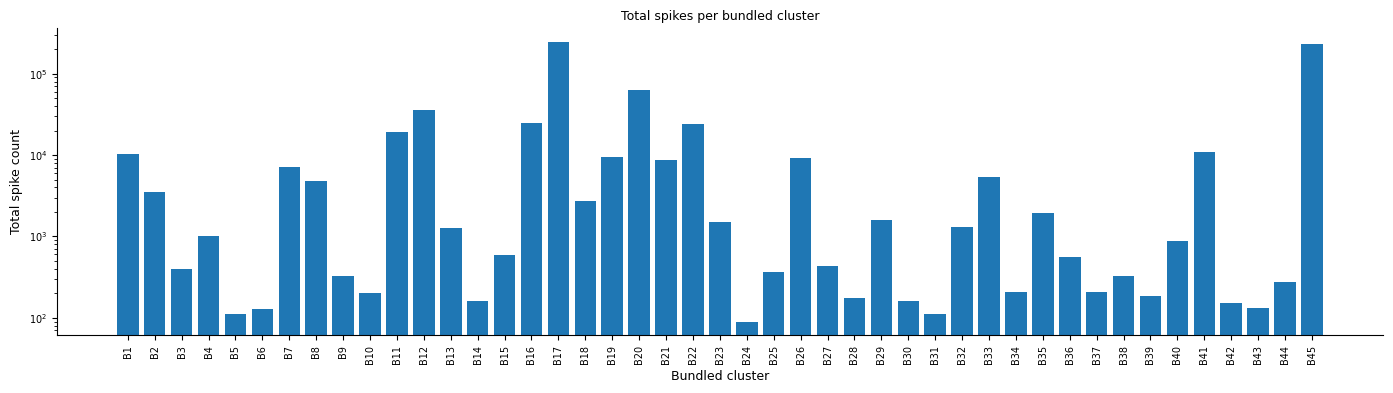

90 242544


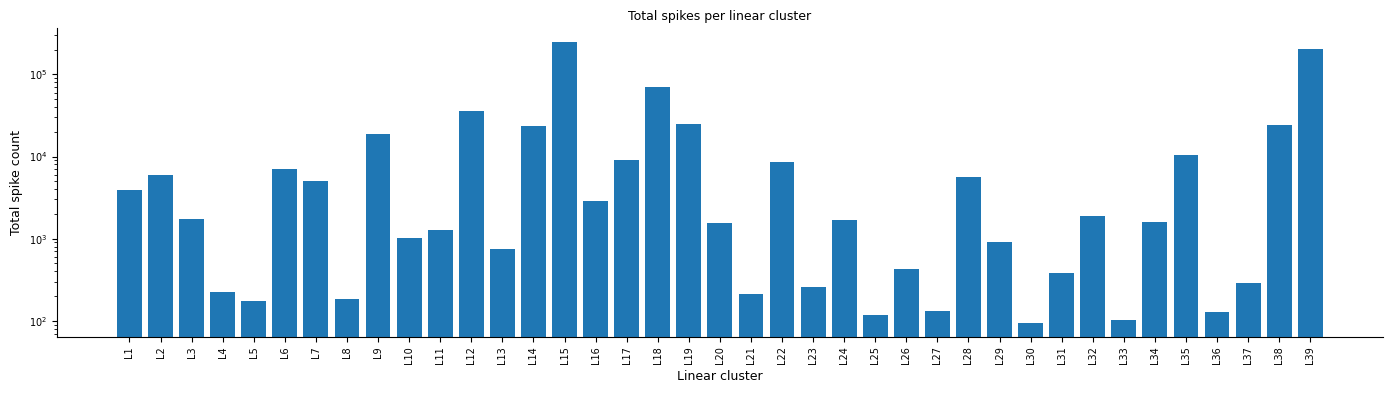

95 245200


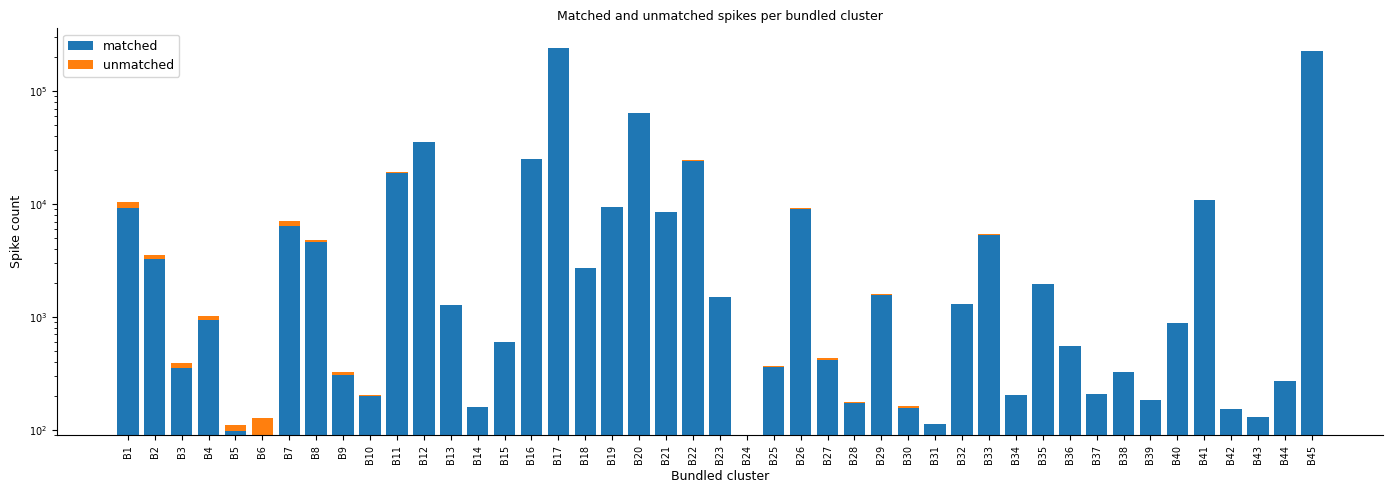

In [91]:
total_bundled = (
    pd.Series(sc_clusters[0])
    .value_counts()
    .rename_axis("bundled_cluster_num")
    .reset_index(name="n_total_spikes")
    .sort_values("bundled_cluster_num")
)

total_bundled["bundled_cluster_id"] = "B" + total_bundled["bundled_cluster_num"].astype(str)

plt.figure(figsize=(14, 4))
plt.bar(total_bundled["bundled_cluster_id"], total_bundled["n_total_spikes"])
plt.xticks(rotation=90)
plt.xlabel("Bundled cluster")
plt.ylabel("Total spike count")
plt.yscale("log")
plt.title("Total spikes per bundled cluster")
plt.tight_layout()
plt.show()
print(np.min(total_bundled["n_total_spikes"]), np.max(total_bundled["n_total_spikes"]))


total_linear = (
    pd.Series(sc_clusters[1])
    .value_counts()
    .rename_axis("linear_cluster_num")
    .reset_index(name="n_total_spikes")
    .sort_values("linear_cluster_num")
)

total_linear["linear_cluster_id"] = "L" + total_linear["linear_cluster_num"].astype(str)

plt.figure(figsize=(14, 4))
plt.bar(total_linear["linear_cluster_id"], total_linear["n_total_spikes"])
plt.xticks(rotation=90)
plt.xlabel("Linear cluster")
plt.ylabel("Total spike count")
plt.yscale("log")
plt.title("Total spikes per linear cluster")
plt.tight_layout()
plt.show()
print(np.min(total_linear["n_total_spikes"]), np.max(total_linear["n_total_spikes"]))

################################

# total spikes per bundled cluster
total_counts = (
    pd.Series(sc_clusters[0])
    .value_counts()
    .rename_axis("bundled_cluster_num")
    .reset_index(name="n_total_spikes")
)

total_counts["bundled_cluster_id"] = (
    "B" + total_counts["bundled_cluster_num"].astype(str)
)

# unmatched bundled spikes per bundled cluster
unmatched_counts = res["unmatched_bundled_counts"].copy()

# if unmatched_counts still uses old numeric column name, convert it
if "bundled_cluster" in unmatched_counts.columns:
    unmatched_counts = unmatched_counts.rename(
        columns={"bundled_cluster": "bundled_cluster_num"}
    )
    unmatched_counts["bundled_cluster_id"] = (
        "B" + unmatched_counts["bundled_cluster_num"].astype(str)
    )

# merge using string ID
plot_df = total_counts.merge(
    unmatched_counts[["bundled_cluster_id", "n_unmatched_bundled_spikes"]],
    on="bundled_cluster_id",
    how="left"
)

plot_df["n_unmatched_bundled_spikes"] = (
    plot_df["n_unmatched_bundled_spikes"].fillna(0).astype(int)
)

plot_df["n_matched_bundled_spikes"] = (
    plot_df["n_total_spikes"] - plot_df["n_unmatched_bundled_spikes"]
)

plot_df = plot_df.sort_values("bundled_cluster_num")

x = np.arange(len(plot_df))

plt.figure(figsize=(14, 5))

plt.bar(
    x,
    plot_df["n_matched_bundled_spikes"],
    label="matched"
)

plt.bar(
    x,
    plot_df["n_unmatched_bundled_spikes"],
    bottom=plot_df["n_matched_bundled_spikes"],
    label="unmatched"
)

plt.xticks(x, plot_df["bundled_cluster_id"], rotation=90)
plt.xlabel("Bundled cluster")
plt.ylabel("Spike count")
plt.title("Matched and unmatched spikes per bundled cluster")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

In [36]:
b_cluster_data[1, :].astype(int)

array([55, 55, 56, 56, 56, 56, 54, 57, 57, 53, 53, 58, 58, 52, 52, 52, 59,
       59, 60, 60, 50, 61, 49, 49, 49, 48, 63, 47, 47, 47, 47, 32, 32, 46,
       46, 46, 46, 46, 46, 46, 33, 45, 45, 45, 39])

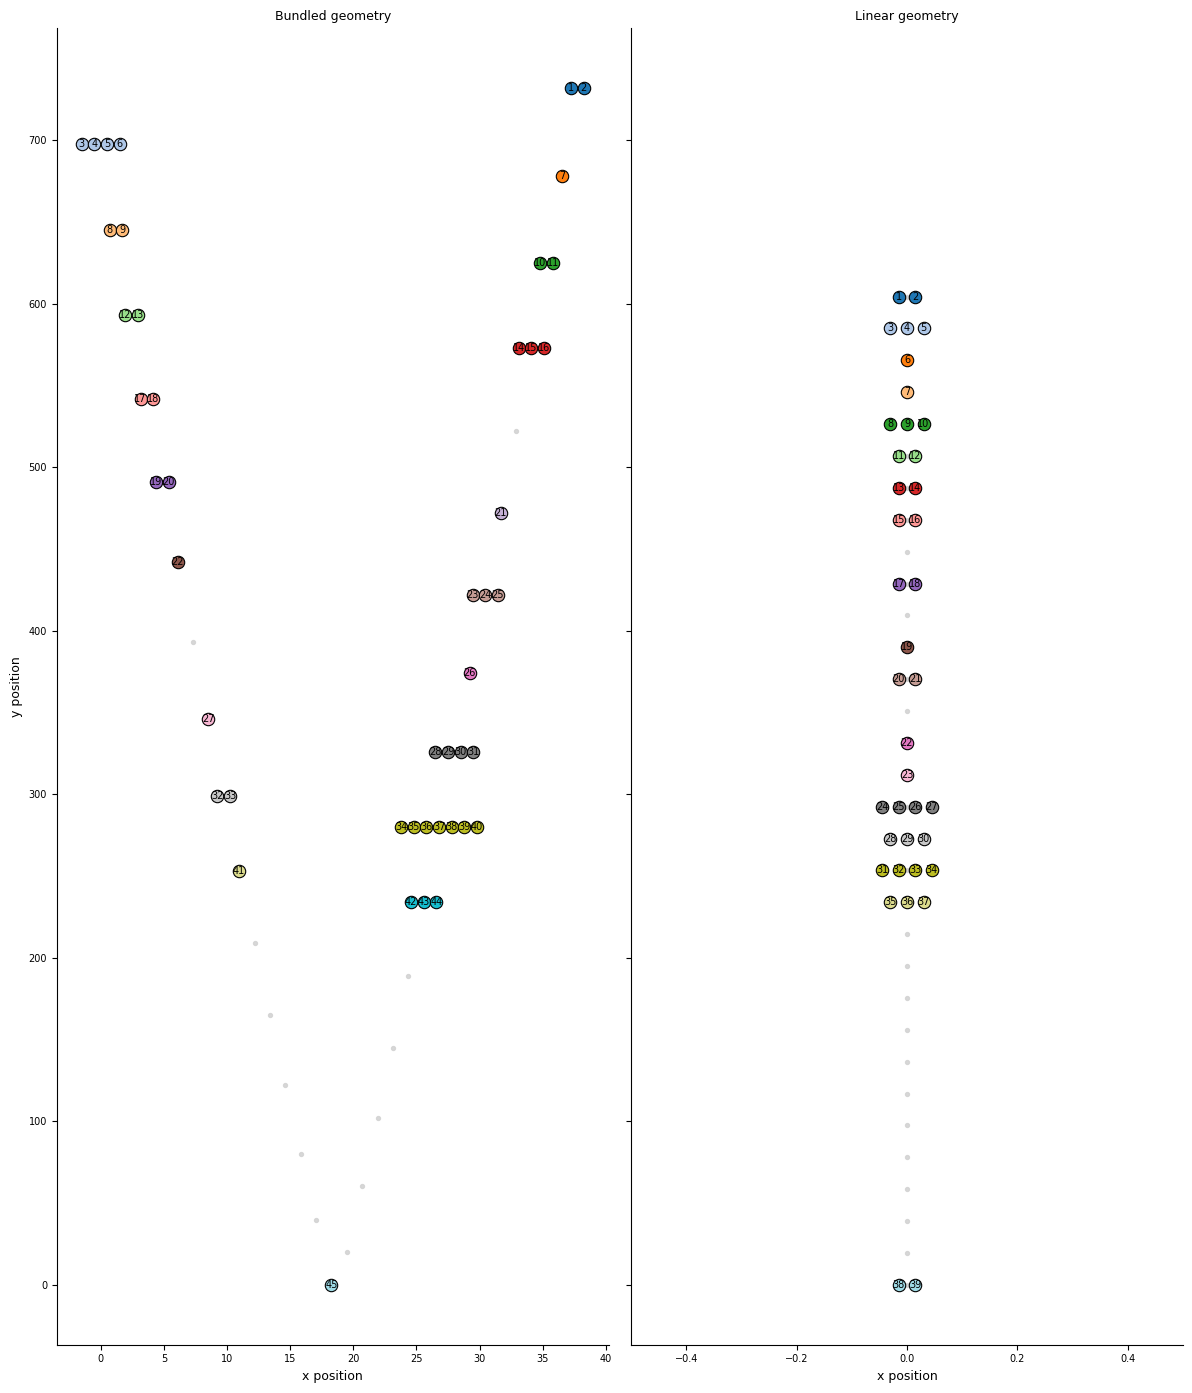

In [131]:
def plot_probe_cluster_locations(
    siteLoc_bundled,
    siteLoc_linear,
    b_cluster_data,
    l_cluster_data,
    x_shift=-3000,
    cluster_id_offset=1,
    figsize=(12, 14),
):
    fig, axs = plt.subplots(1, 2, figsize=figsize, sharey=True)

    b_peak_indices = b_cluster_data[2, :].astype(int)  
    l_peak_indices = l_cluster_data[2, :].astype(int)
    all_peak_ids = np.unique(np.r_[b_peak_indices, l_peak_indices])
    cmap = plt.get_cmap("tab20", len(all_peak_ids))
    color_map = {pid: cmap(i) for i, pid in enumerate(all_peak_ids)}

    panels = [
        (axs[0], np.asarray(siteLoc_bundled), "Bundled geometry", b_peak_indices, 1),
        (axs[1], np.asarray(siteLoc_linear), "Linear geometry", l_peak_indices, 0.03),
    ]

    for ax, geom, title, peak_ids, marker_space in panels:
        x = geom[32:, 0] + x_shift
        y = geom[32:, 1]

        # Plot all probe sites
        ax.scatter(
            x,
            y,
            s=8,
            c="lightgray",
            alpha=0.9,
            label="Probe sites",
            zorder=1,
        )

        # For each peak channel, find which clusters sit there
        unique_peak_ids = np.unique(peak_ids)
        
        for peak_id in unique_peak_ids:
            cluster_inds = np.where(peak_ids == peak_id)[0]
            n = len(cluster_inds)

            offsets = (np.arange(n) - (n-1) /2) * marker_space

            for offset, cluster_ind in zip(offsets, cluster_inds):
                cx = geom[:,0][peak_id] - 3000 + offset
                cy = geom[:,1][peak_id]

                label = cluster_ind + cluster_id_offset

                ax.scatter(
                    cx,
                    cy,
                    s=80,
                    color = color_map[peak_id],
                    edgecolor="black",
                    linewidth=0.8,
                    zorder=3,
                )

                ax.text(
                    cx,
                    cy,
                    str(label),
                    ha="center",
                    va="center",
                    fontsize=7,
                    zorder=4,
                )

        ax.set_title(title)
        ax.set_xlabel("x position")
        if title == "Linear geometry":
            ax.set_xlim(-0.5, 0.5)

    axs[0].set_ylabel("y position")
    

    plt.tight_layout()
    plt.savefig('geometry_clusters.pdf', bbox_inches='tight', dpi=300)

    plt.show()

plot_probe_cluster_locations(
    siteLoc_bundled,
    siteLoc_linear,
    b_cluster_data,
    l_cluster_data,
)

/var/folders/v5/2v2dc07n6q5fb1dqj502cfh80000gn/T/ipykernel_38304/3103501698.py:54: RuntimeWarning: divide by zero encountered in log10
  log_data = np.log10(masked + 1)


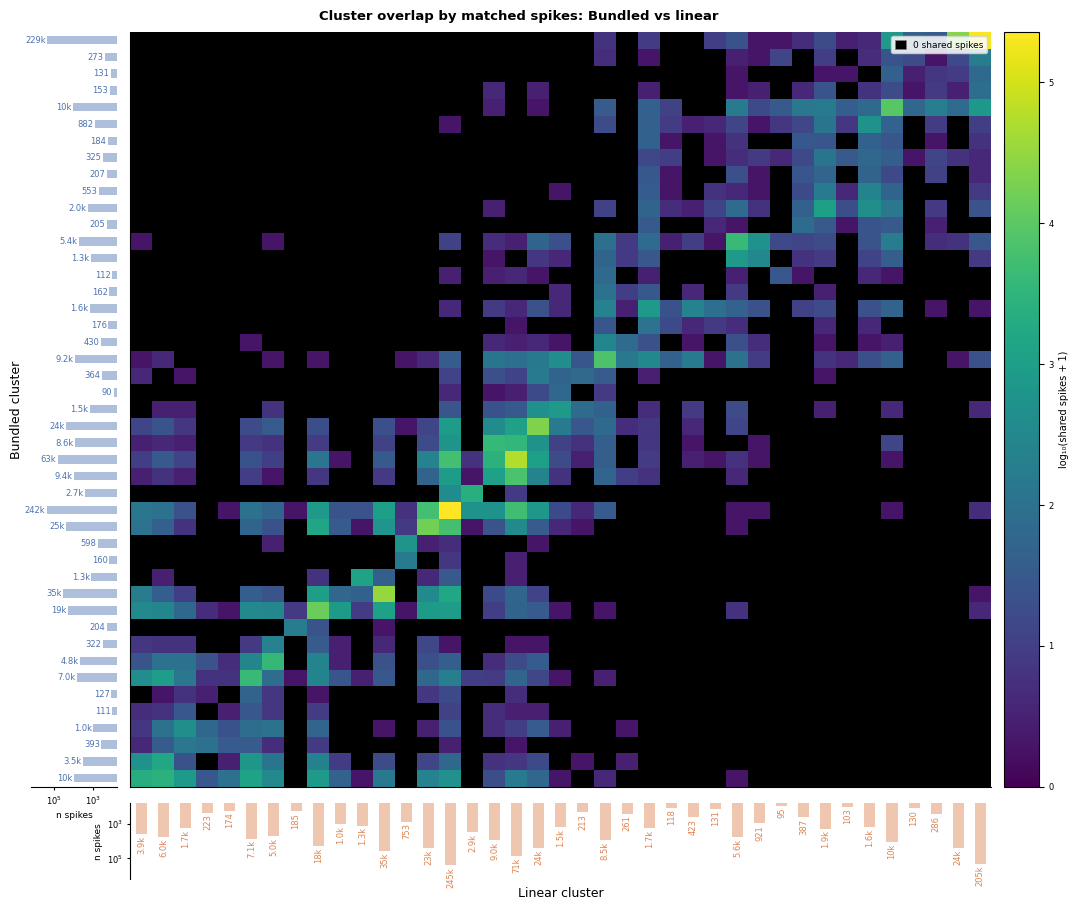

Saved: overlap_heatmap.pdf / .png


In [118]:
"""
Cluster overlap heatmap with marginal spike-count bars.

Layout:
  Left strip   — bundled cluster n_spikes (log, bars grow leftward)
  Main panel   — log10(shared spikes + 1) heatmap; zeros masked black
  Bottom strip — linear cluster n_spikes (log, bars grow downward)

Requires:
  res                                   — output of compare_cluster_assignments()
  bundled_df_metrics, linear_df_metrics — from compute_unit_metrics()
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

# ── Style ─────────────────────────────────────────────────────────────────────
COL_B    = '#4C72B0'
COL_L    = '#DD8452'
FS_LABEL = 9
FS_TICK  = 7

plt.rcParams.update({
    'font.size':         FS_LABEL,
    'axes.labelsize':    FS_LABEL,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

def fmt_n(n):
    """Compact spike-count label: 1234 → '1.2k', 45000 → '45k'."""
    if n >= 10_000: return f'{int(n) // 1000}k'
    if n  >= 1_000: return f'{n / 1000:.1f}k'
    return str(int(n))

# ── Build pivot matrix ────────────────────────────────────────────────────────
overlap = res['overlap']

mat = overlap.pivot_table(
    index   ='bundled_cluster',
    columns ='linear_cluster',
    values  ='n_shared_spikes',
    fill_value=0,
    aggfunc='sum',
).sort_index(axis=0).sort_index(axis=1)

raw = mat.to_numpy().astype(float)

masked   = np.ma.masked_where(raw == 0, raw)
log_data = np.log10(masked + 1)

bundled_ids = mat.index.tolist()
linear_ids  = mat.columns.tolist()
n_b, n_l    = len(bundled_ids), len(linear_ids)

# ── n_spikes per cluster ──────────────────────────────────────────────────────
b_lookup = bundled_df_metrics.set_index('unit_id')['n_spikes']
l_lookup = linear_df_metrics.set_index('unit_id')['n_spikes']

b_n = np.array([b_lookup.get(c, 1) for c in bundled_ids])
l_n = np.array([l_lookup.get(c, 1) for c in linear_ids])

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 11))
gs  = gridspec.GridSpec(
    2, 3,
    figure        = fig,
    width_ratios  = [0.10, 1, 0.04],
    height_ratios = [1, 0.10],
    hspace        = 0.04,          # tight gap — alignment is handled by sharex/sharey
    wspace        = 0.04,
)

ax_main   = fig.add_subplot(gs[0, 1])
ax_left   = fig.add_subplot(gs[0, 0], sharey=ax_main)
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_main)
ax_cbar   = fig.add_subplot(gs[0, 2])   # dedicated colorbar axes
ax_corner = fig.add_subplot(gs[1, 0])
ax_corner.axis('off')

# ── Main heatmap ──────────────────────────────────────────────────────────────
cmap = plt.cm.viridis.copy()
cmap.set_bad('black')

im = ax_main.imshow(
    log_data,
    aspect        = 'auto',
    origin        = 'lower',
    cmap          = cmap,
    interpolation = 'nearest',
    vmin          = 0,
)

# Explicit limits — sharex/sharey will propagate these to the strip axes
ax_main.set_xlim(-0.5, n_l - 0.5)
ax_main.set_ylim(-0.5, n_b - 0.5)

# Unit ID tick labels — sit close to the heatmap edges
ax_main.set_xticks(np.arange(n_l))
ax_main.set_xticklabels(linear_ids,  fontsize=5.5, rotation=90)
ax_main.set_yticks(np.arange(n_b))
ax_main.set_yticklabels(bundled_ids, fontsize=5.5)
ax_main.tick_params(length=2, pad=2)
# Axis labels removed from heatmap — moved to outer strips below
ax_main.set_xlabel('')
ax_main.set_ylabel('')

cbar = fig.colorbar(im, cax=ax_cbar)   # cax= uses pre-allocated axes, never resizes ax_main
cbar.set_label('log₁₀(shared spikes + 1)', fontsize=7)
cbar.ax.tick_params(labelsize=6)

zero_patch = Patch(facecolor='black', edgecolor='grey', linewidth=0.5,
                   label='0 shared spikes')
ax_main.legend(handles=[zero_patch], fontsize=6.5, frameon=True,
               framealpha=0.85, edgecolor='lightgrey',
               loc='upper right', handlelength=1.2, handleheight=1.2)

# ── Left marginal: bundled n_spikes ──────────────────────────────────────────
y_pos = np.arange(n_b)

ax_left.barh(y_pos, b_n, color=COL_B, alpha=0.45, height=0.5)
ax_left.set_xscale('log')
ax_left.invert_xaxis()
ax_left.set_yticks([])

# "Bundled cluster" label goes on the y-axis — to the far left of this strip
ax_left.set_ylabel('Bundled cluster', fontsize=FS_LABEL, labelpad=6)
ax_left.set_xlabel('n spikes', fontsize=6.5, labelpad=3)
ax_left.tick_params(axis='x', labelsize=6, length=2)

ax_left.spines['top'].set_visible(False)
ax_left.spines['left'].set_visible(False)

# Tip labels: sit just beyond the left end of each bar
ax_left.set_xlim(max(b_n) * 6, ax_left.get_xlim()[1])
for y, n in zip(y_pos, b_n):
    # n*1.2 is slightly left of bar tip in display (larger x = further left when inverted)
    ax_left.text(n * 1.2, y, fmt_n(n),
                 ha='right', va='center', fontsize=6, color=COL_B)

# ── Bottom marginal: linear n_spikes ──────────────────────────────────────────
x_pos = np.arange(n_l)

ax_bottom.bar(x_pos, l_n, color=COL_L, alpha=0.45, width=0.5)
ax_bottom.set_yscale('log')
ax_bottom.invert_yaxis()
ax_bottom.set_xticks([])

# "Linear cluster" label goes on the x-axis — below this strip
ax_bottom.set_xlabel('Linear cluster', fontsize=FS_LABEL, labelpad=6)
ax_bottom.set_ylabel('n spikes', fontsize=6.5, labelpad=3)
ax_bottom.tick_params(axis='y', labelsize=6, length=2)
ax_bottom.spines['bottom'].set_visible(False)
ax_bottom.spines['right'].set_visible(False)

# Tip labels: sit just beyond the bottom of each bar
ax_bottom.set_ylim(max(l_n) * 6, ax_bottom.get_ylim()[1])
for x, n in zip(x_pos, l_n):
    ax_bottom.text(x, n * 1.2, fmt_n(n),
                   ha='center', va='top', fontsize=6,
                   color=COL_L, rotation=90)

# ── Title ─────────────────────────────────────────────────────────────────────
fig.suptitle(
    'Cluster overlap by matched spikes: Bundled vs linear',
    fontsize=9.5, fontweight='bold', y=0.9,
)

plt.savefig('overlap_heatmap.pdf', bbox_inches='tight', dpi=300)
plt.savefig('overlap_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: overlap_heatmap.pdf / .png")

For further visualization on the composition of each linear cluster in relation to bundled clusters. This is a valid analysis as each spike in a linear cluster exists in a bundled cluster as determined previously. 

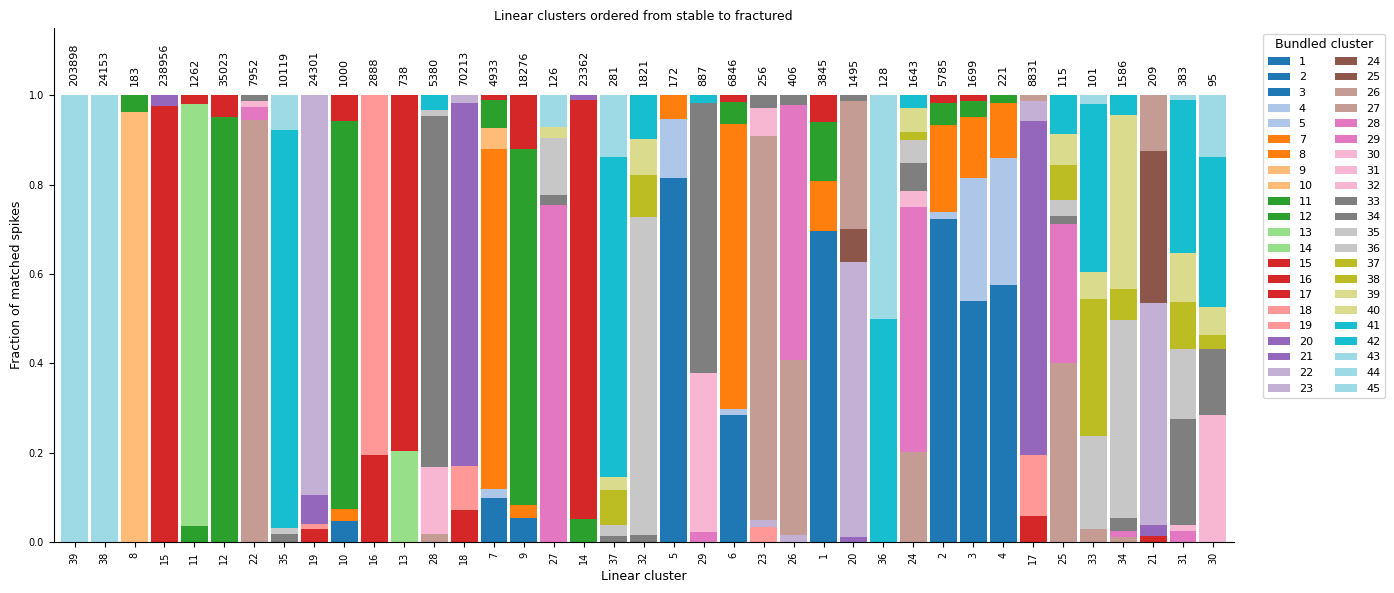

In [130]:
def plot_linear_to_bundled_stacked_sorted(
    overlap,
    min_frac=0.01,
    normalize=True,
    figsize=(14, 6),
):
    df = overlap.copy()

    df = df[df["frac_of_linear"] >= min_frac]

    mat = df.pivot_table(
        index="linear_cluster",
        columns="bundled_cluster",
        values="n_shared_spikes",
        aggfunc="sum",
        fill_value=0,
    )

    frac_mat = mat.div(mat.sum(axis=1), axis=0)

    # Higher max fraction = more solid/stable cluster
    solidity = frac_mat.max(axis=1)

    # Left = most solid, right = most fractured
    order = solidity.sort_values(ascending=False).index

    mat = mat.loc[order]
    totals = mat.sum(axis=1) # before normalization 
    
    if normalize:
        mat = mat.div(mat.sum(axis=1), axis=0)

    ax = mat.plot(
        kind="bar",
        stacked=True,
        figsize=figsize,
        width=0.9,
        colormap="tab20",
    )

    ax.set_xlabel("Linear cluster")
    ax.set_ylabel("Fraction of matched spikes" if normalize else "Shared spikes")
    ax.set_title("Linear clusters ordered from stable to fractured")
    
    

    y_offset = 0.02 if normalize else totals.max() * 0.01
    ax.set_ylim(0, 1.15)

    for i, total in enumerate(totals):
        y = 1 if normalize else total
        ax.text(
            i,
            y + y_offset,
            f"{int(total)}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

    ax.legend(
        title="Bundled cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
        ncol=2,
    )

    plt.tight_layout()
    plt.savefig('bundled_clusters.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    return solidity.loc[order]
    
solid_loc_order = plot_linear_to_bundled_stacked_sorted(res["overlap"])

stop


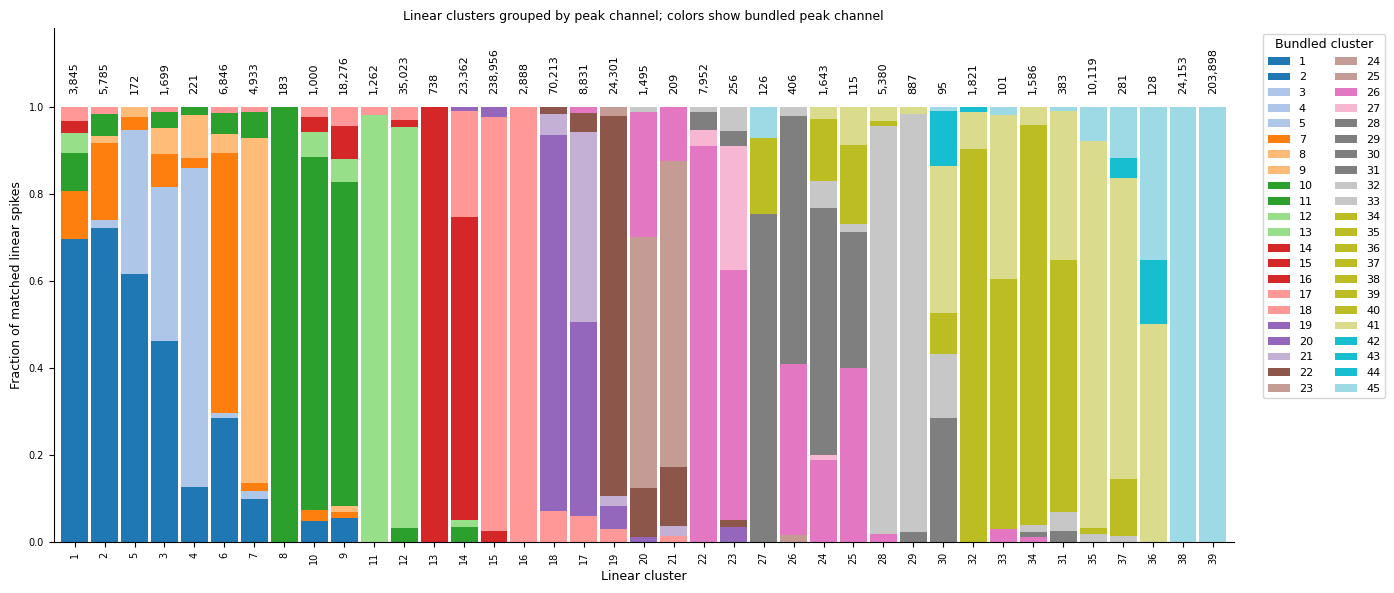

In [120]:
import numpy as np
import matplotlib.pyplot as plt

def peak_maps_from_groups(clusters):
    b_peak, l_peak = {}, {}

    for group in clusters:
        chan = group[0][3]

        for item in group:
            sorter_id = item[0]      # 0 = bundled, 1 = linear
            cluster_id = item[1]     # cluster index

            if sorter_id == 0:
                b_peak[cluster_id] = chan
            else:
                l_peak[cluster_id] = chan

    return b_peak, l_peak

def plot_linear_to_bundled_by_peak_channel(
    overlap,
    clusters,
    min_frac=0.01,
    order_by="peak_then_solidity",   # or "solidity"
    figsize=(14, 6),
):
    b_peak, l_peak = peak_maps_from_groups(clusters)
    print("stop")

    df = overlap.loc[overlap["frac_of_linear"] >= min_frac].copy()

    mat_counts = df.pivot_table(
        index="linear_cluster",
        columns="bundled_cluster",
        values="n_shared_spikes",
        aggfunc="sum",
        fill_value=0,
    )

    totals = mat_counts.sum(axis=1)
    mat_frac = mat_counts.div(totals, axis=0)

    solidity = mat_frac.max(axis=1)

    if order_by == "peak_then_solidity":
        order = sorted(
            mat_frac.index,
            key=lambda c: (
                l_peak.get(c, np.inf),
                -solidity.loc[c],
            ),
        )
    elif order_by == "solidity":
        order = solidity.sort_values(ascending=False).index
    else:
        order = mat_frac.index

    mat_frac = mat_frac.loc[order]
    totals = totals.loc[order]
    solidity = solidity.loc[order]

    # One color per bundled peak channel
    peak_channels = sorted({b_peak.get(c) for c in mat_frac.columns})
    cmap = plt.get_cmap("tab20", len(peak_channels))
    peak_to_color = {ch: cmap(i) for i, ch in enumerate(peak_channels)}
    colors = [peak_to_color[b_peak.get(c)] for c in mat_frac.columns]

    ax = mat_frac.plot(
        kind="bar",
        stacked=True,
        figsize=figsize,
        width=0.9,
        color=colors,
    )

    ax.set_xlabel("Linear cluster")
    ax.set_ylabel("Fraction of matched linear spikes")
    ax.set_title("Linear clusters grouped by peak channel; colors show bundled peak channel")
    ax.set_ylim(0, 1.18)

    for i, total in enumerate(totals):
        ax.text(
            i,
            1.03,
            f"{int(total):,}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

    ax.legend(
        title="Bundled cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
        ncol=2,
    )

    plt.tight_layout()
    plt.show()

    return solidity

clusters = cluster_units_by_channel_radius(
    unit_arrays=[b_cluster_data.T, l_cluster_data.T],
    chan_map=siteMap_bundled,
    radius=0,
)


solid_loc_order = plot_linear_to_bundled_by_peak_channel(
    res["overlap"],
    clusters,
    min_frac=0.01,
    order_by="peak_then_solidity")

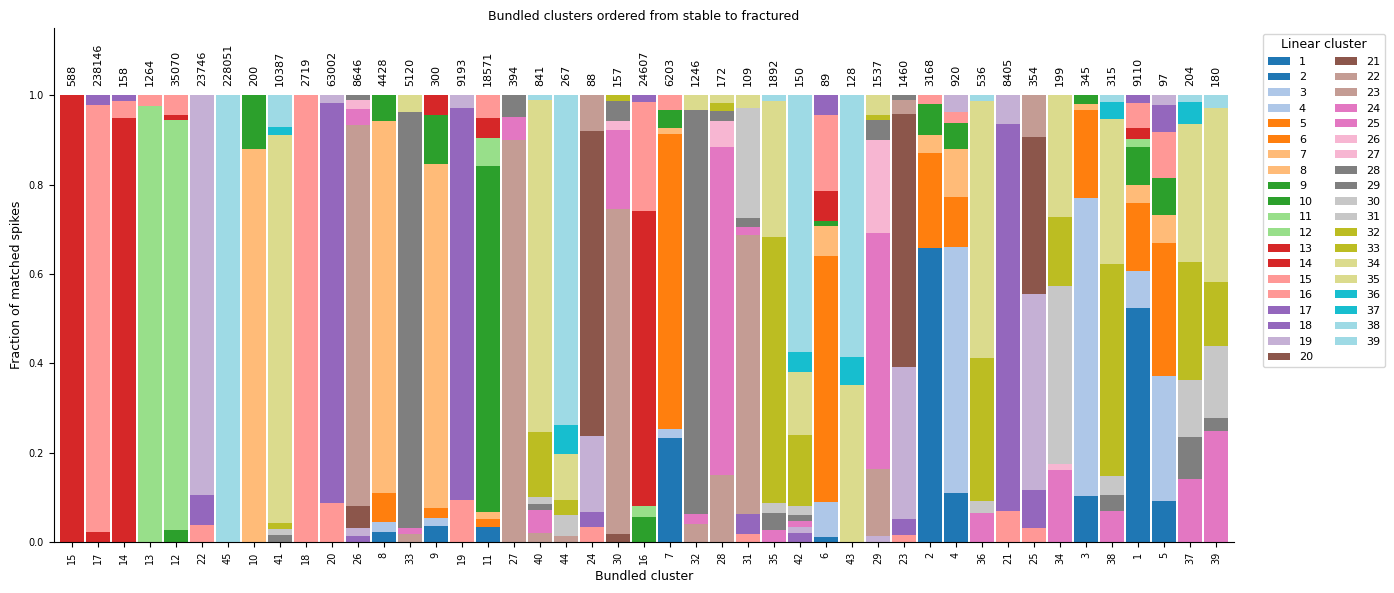

In [123]:
def plot_bundled_to_linear_stacked_sorted(
    overlap,
    min_frac=0.01,
    normalize=True,
    figsize=(14, 6),
):
    df = overlap.copy()
    df = df[df["frac_of_bundled"] >= min_frac]

    mat = df.pivot_table(
        index="bundled_cluster",       # ← swapped
        columns="linear_cluster",      # ← swapped
        values="n_shared_spikes",
        aggfunc="sum",
        fill_value=0,
    )

    frac_mat = mat.div(mat.sum(axis=1), axis=0)
    solidity = frac_mat.max(axis=1)
    order = solidity.sort_values(ascending=False).index

    mat = mat.loc[order]
    totals = mat.sum(axis=1)

    if normalize:
        mat = mat.div(mat.sum(axis=1), axis=0)

    ax = mat.plot(
        kind="bar",
        stacked=True,
        figsize=figsize,
        width=0.9,
        colormap="tab20",
    )

    ax.set_xlabel("Bundled cluster")
    ax.set_ylabel("Fraction of matched spikes" if normalize else "Shared spikes")
    ax.set_title("Bundled clusters ordered from stable to fractured")

    y_offset = 0.02 if normalize else totals.max() * 0.01
    ax.set_ylim(0, 1.15)

    for i, total in enumerate(totals):
        y = 1 if normalize else total
        ax.text(i, y + y_offset, f"{int(total)}",
                ha="center", va="bottom", fontsize=8, rotation=90)

    ax.legend(
        title="Linear cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
        ncol=2,
    )

    plt.tight_layout()
    plt.show()
    return solidity.loc[order]

solidity_bundled = plot_bundled_to_linear_stacked_sorted(res["overlap"])

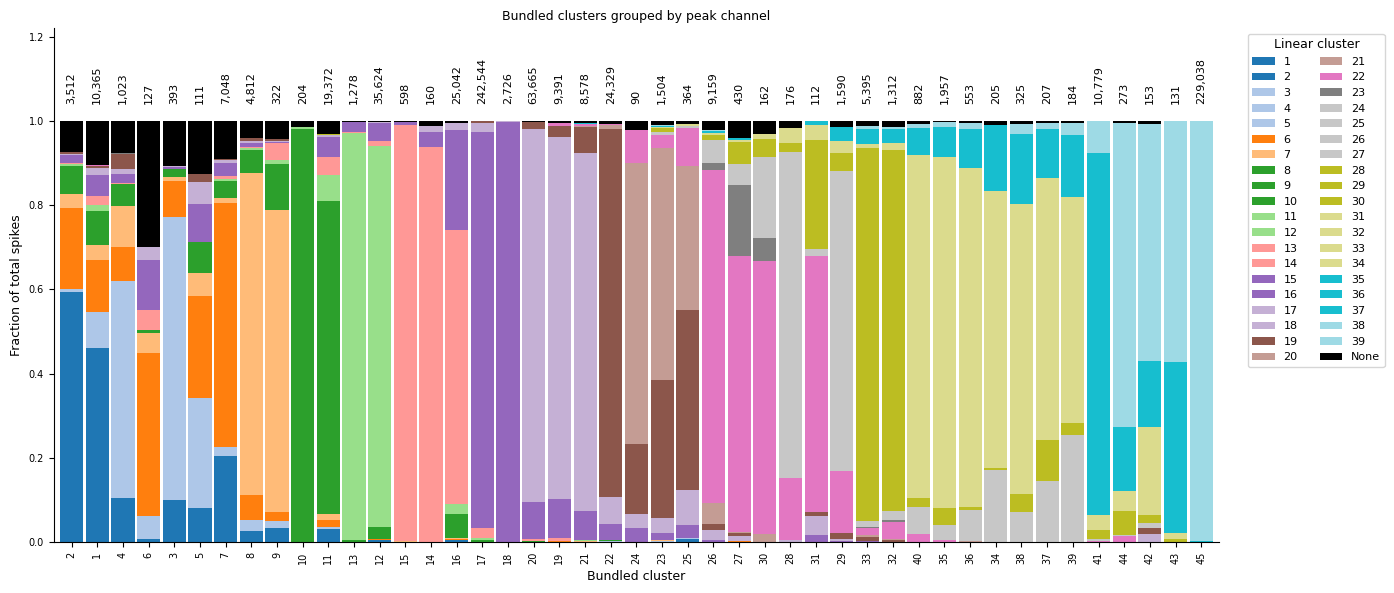

In [129]:
def plot_bundled_to_linear_by_peak_channel(
    overlap,
    clusters,
    bundled_n_spikes=None,   # dict / Series {cluster_id: total n_spikes}
    unmatched_counts=None,   # dict / Series {cluster_id: n_unmatched_spikes}
                             #   → pass res["unmatched_bundled_counts"]
                             #     .set_index("bundled_cluster")["n_unmatched_bundled_spikes"]
    min_frac=0.01,
    order_by="peak_then_solidity",
    figsize=(14, 6),
):
    """
    Stacked bar chart of bundled cluster composition.

    Each bar = one bundled cluster.
    Coloured segments = fraction of spikes shared with each linear cluster
                        (colour = linear peak channel).
    Black segment     = fraction of spikes with no match in any linear cluster
                        (geometry-exclusive detections).

    Normalisation:
      If bundled_n_spikes is supplied, fractions are relative to the TOTAL
      spike count of each bundled cluster, so coloured + black = 1.0.
      If not supplied, falls back to fraction of matched spikes only (black
      segment is omitted).
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    b_peak, l_peak = peak_maps_from_groups(clusters)

    # ── Filter overlap to significant contributions ───────────────────────────
    df = overlap.loc[overlap["frac_of_bundled"] >= min_frac].copy()

    mat_counts = df.pivot_table(
        index      = "bundled_cluster",
        columns    = "linear_cluster",
        values     = "n_shared_spikes",
        aggfunc    = "sum",
        fill_value = 0,
    )

    # ── Normalise ─────────────────────────────────────────────────────────────
    if bundled_n_spikes is not None:
        n_total  = pd.Series(bundled_n_spikes).reindex(mat_counts.index)
        mat_frac = mat_counts.div(n_total, axis=0)      # fraction of ALL spikes
    else:
        totals   = mat_counts.sum(axis=1)
        mat_frac = mat_counts.div(totals, axis=0)       # fraction of matched only

    # ── Unmatched fraction ────────────────────────────────────────────────────
    if bundled_n_spikes is not None and unmatched_counts is not None:
        unmatched_s = pd.Series(unmatched_counts).reindex(
            mat_counts.index, fill_value=0
        )
        n_total_s = pd.Series(bundled_n_spikes).reindex(mat_counts.index)
        unmatched_frac = (unmatched_s / n_total_s).clip(lower=0)
    else:
        unmatched_frac = None

    # ── Solidity & ordering ───────────────────────────────────────────────────
    solidity = mat_frac.max(axis=1)

    if order_by == "peak_then_solidity":
        order = sorted(
            mat_frac.index,
            key=lambda c: (b_peak.get(c, np.inf), -solidity.loc[c]),
        )
    elif order_by == "solidity":
        order = solidity.sort_values(ascending=False).index
    else:
        order = mat_frac.index

    mat_frac  = mat_frac.loc[order]
    solidity  = solidity.loc[order]

    if bundled_n_spikes is not None:
        totals_plot = pd.Series(bundled_n_spikes).reindex(order)
    else:
        totals_plot = mat_counts.sum(axis=1).loc[order]

    # ── Colours (one per linear peak channel) ────────────────────────────────
    peak_channels = sorted({l_peak.get(c) for c in mat_frac.columns})
    cmap          = plt.get_cmap("tab20", len(peak_channels))
    peak_to_color = {ch: cmap(i) for i, ch in enumerate(peak_channels)}
    colors        = [peak_to_color[l_peak.get(c)] for c in mat_frac.columns]

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    mat_frac.plot(
        kind   = "bar",
        stacked= True,
        ax     = ax,
        width  = 0.9,
        color  = colors,
        legend = True,
    )

    # Black segment for unmatched spikes on top of each bar
    if unmatched_frac is not None:
        bottoms = mat_frac.sum(axis=1).values          # top of stacked matched bars
        ax.bar(
            range(len(order)),
            unmatched_frac.loc[order].values,
            bottom = bottoms,
            color  = 'black',
            width  = 0.9,
            label  = 'Unmatched (bundled-exclusive)',
            zorder = 3,
        )

    # ── Labels ────────────────────────────────────────────────────────────────
    ax.set_xlabel("Bundled cluster")
    ax.set_ylabel(
        "Fraction of total spikes" if bundled_n_spikes is not None
        else "Fraction of matched bundled spikes"
    )
    ax.set_title(
        "Bundled clusters grouped by peak channel"
    )
    ax.set_ylim(0, 1.22)

    # Total spike count above each bar
    for i, total in enumerate(totals_plot):
        ax.text(i, 1.04, f"{int(total):,}",
                ha="center", va="bottom", fontsize=8, rotation=90)

    # Legend — add black patch manually so it appears even if some bars have 0
    from matplotlib.patches import Patch
    handles, labels = ax.get_legend_handles_labels()
    if unmatched_frac is not None:
        # remove auto-added black entry (already appended by bar()) then re-add cleanly
        handles = [h for h, l in zip(handles, labels)
                   if l != 'Unmatched (bundled-exclusive)']
        labels  = [l for l in labels
                   if l != 'Unmatched (bundled-exclusive)']
        handles.append(Patch(facecolor='black', label='Unmatched'))
        labels.append('None')

    ax.legend(
        handles,
        labels,
        title          = "Linear cluster",
        bbox_to_anchor = (1.02, 1),
        loc            = "upper left",
        fontsize       = 8,
        ncol           = 2,
    )

    plt.tight_layout()
    plt.show()
    return solidity


# ── Call ──────────────────────────────────────────────────────────────────────
# Build lookup Series for total spikes per bundled cluster
b_n_spikes = bundled_df_metrics.set_index('unit_id')['n_spikes']

# Unmatched counts per bundled cluster (from compare_cluster_assignments output)
unmatched_per_cluster = (
    res["unmatched_bundled_counts"]
    .set_index("bundled_cluster")["n_unmatched_bundled_spikes"]
)

solidity_bundled = plot_bundled_to_linear_by_peak_channel(
    res["overlap"],
    clusters,
    bundled_n_spikes = b_n_spikes,
    unmatched_counts = unmatched_per_cluster,
    min_frac         = 0.00,
    order_by         = "peak_then_solidity",
)

***
We'll start by analyzing cluster B17 and L15 

In [115]:
B_unit_id = 17
L_unit_id = 15

B_unit_data = extract_unit_data_JRCLUST(res_mat_path=bundled_res_mat_path, spikesFilt_mat_path=bundled_spikesFilt_path, siteMap = siteMap_bundled, cluster_id=B_unit_id)
L_unit_data = extract_unit_data_JRCLUST(res_mat_path=linear_res_mat_path, spikesFilt_mat_path=linear_spikesFilt_path, siteMap = siteMap_linear, cluster_id=L_unit_id)

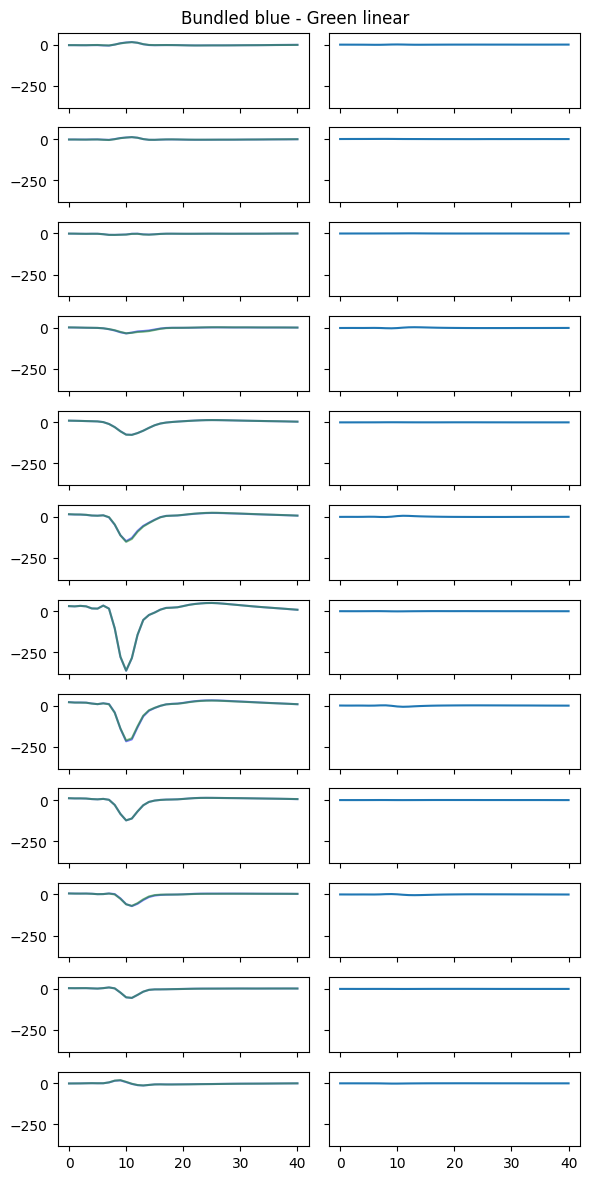

In [116]:
# plot waveforms (shape = 242544, 12, 41)

lin_indices_order = [11, 9, 7, 5, 3, 1, 0, 2, 4, 6, 8, 10]
bund_indices_order = [11, 10, 8, 6, 4, 2, 0, 1, 3, 5, 7, 9]
fig, axes = plt.subplots(12, 2, figsize=(6, 12), sharex=True, sharey=True)

mean_b =  np.mean(B_unit_data["spike_waveforms"], axis=0)
mean_l = np.mean(L_unit_data["spike_waveforms"], axis=0)

for i in range(12):   
    axes[i, 0].plot(np.arange(41), mean_b[bund_indices_order[i]], alpha=0.5, color="blue")
    axes[i, 0].plot(np.arange(41), mean_l[lin_indices_order[i]], alpha=0.5, color='green')
    axes[i, 1].plot(np.arange(41), mean_b[bund_indices_order[i]]-mean_l[lin_indices_order[i]])

plt.suptitle("Bundled blue - Green linear")
plt.tight_layout()
plt.show()

In [ ]:
out = identical_spikes(B_unit_data["spike_times"], L_unit_data["spike_times"])
idx_B = out[:, 0] # indicies of B_unit spike times that are identical to L_unit spike times
idx_L = out[:, 1] # indices of L_unit spike times that are identical to B_unit spike times

# print how many spikes are matched between the two clusters 
print(f"Bundled cluster {B_unit_id} has {B_unit_data['spike_times'].shape[0]} spikes total, {len(idx_B)} are shared with the cluster L ({len(idx_B)/B_unit_data['spike_times'].shape[0] * 100}%)")
print(f"Linear cluster {L_unit_id} has {L_unit_data['spike_times'].shape[0]} spikes total; {len(idx_L)/L_unit_data['spike_times'].shape[0] * 100}% shared with cluster B")

# because these matching spikes will have very similar waveforms, we will focus our analysis on the spikes that are not common to both units 
        # there are extra spikes from the linear cluster (which have a matched spike in another bundled cluster)
        # and there are extra spikes from the bundled cluster that may or may not have a match in another linear cluster 
        
# get the sample value of B spikes that are in unit cluster but not in L unit 
B_in_clus_matching_mask = np.zeros(len(B_unit_data["spike_times"]), dtype=bool)
B_in_clus_matching_mask[idx_B] = True

unmatched_in_Bclus_samples = B_unit_data["spike_times"][~B_in_clus_matching_mask] # total b unit spikes - those that match with L cluster 

# get the sample value of L spikes that are in unit cluster but not in B unit 
L_in_clus_matching_mask = np.zeros(len(L_unit_data["spike_times"]), dtype=bool)
L_in_clus_matching_mask[idx_L] = True

unmatched_in_Lclus_samples = L_unit_data["spike_times"][~L_in_clus_matching_mask] # total l unit spikes - those that match with B cluster 

print(unmatched_in_Bclus_samples.shape, unmatched_in_Lclus_samples.shape)

#########################################
# look at the waveforms of the spikes that aren't matching 
unit_b_unmatched_waveforms = B_unit_data["spike_waveforms"][~B_in_clus_matching_mask]
unit_l_unmatched_waveforms = L_unit_data["spike_waveforms"][~L_in_clus_matching_mask]

# plot the correlation of each of these spike waveforms to those of the mean matching spike waveform 
unit_b_matched_mean_waveform =  np.mean(B_unit_data["spike_waveforms"][B_in_clus_matching_mask], axis=0) # (shape 12x41)
unit_l_matched_mean_waveform = np.mean(L_unit_data["spike_waveforms"][L_in_clus_matching_mask], axis=0)

# euclidean distance (sum over multiple channels)
# correlation (though measures change not amplitude for example) 
# cosine similarity 
# mahalanobis distance 

import numpy as np

def waveform_template_metrics(waveforms, template=None):
    """
    waveforms: array, shape (n_spikes, n_channels, n_samples)
    template: optional array, shape (n_channels, n_samples)

    returns:
        corr: correlation of each waveform to template
        cosine: cosine similarity of each waveform to template
        l2: Euclidean distance to template
        amplitude: peak-to-trough amplitude per waveform
    """

    waveforms = np.asarray(waveforms)

    if template is None:
        template = waveforms.mean(axis=0)

    # Flatten 12 x 41 -> 492
    W = waveforms.reshape(waveforms.shape[0], -1)
    T = template.reshape(-1)

    # Pearson correlation to template
    W_centered = W - W.mean(axis=1, keepdims=True)
    T_centered = T - T.mean()

    corr = (
        W_centered @ T_centered
        / (
            np.linalg.norm(W_centered, axis=1)
            * np.linalg.norm(T_centered)
        )
    )

    # Cosine similarity to template
    cosine = (
        W @ T
        / (
            np.linalg.norm(W, axis=1)
            * np.linalg.norm(T)
        )
    )

    # Euclidean distance to template
    l2 = np.linalg.norm(W - T, axis=1)

    # Peak-to-trough amplitude across all channels and samples
    amplitude = waveforms.max(axis=(1, 2)) - waveforms.min(axis=(1, 2))
    
    np.where(corr == np.min(corr))

    return {
        "corr": corr,
        "cosine": cosine,
        "l2": l2,
        "amplitude": amplitude,
        "template": template,
        "least_corr": waveforms[np.where(corr == np.min(corr))],
        "most_corr": waveforms[np.where(corr == np.max(corr))]
    }



metrics_shared = waveform_template_metrics(B_unit_data["spike_waveforms"][B_in_clus_matching_mask])

metrics_B_only = waveform_template_metrics(unit_b_unmatched_waveforms, template=np.mean(B_unit_data["spike_waveforms"], axis=0))
metrics_L_only = waveform_template_metrics(unit_l_unmatched_waveforms, template=np.mean(L_unit_data["spike_waveforms"], axis=0))


lin_indices_order = [11, 9, 7, 5, 3, 1, 0, 2, 4, 6, 8, 10]
bund_indices_order = [11, 10, 8, 6, 4, 2, 0, 1, 3, 5, 7, 9]

fig, axes = plt.subplots(12, 2, figsize=(6, 12), sharex=True, sharey=True)

for i in range(12):   
    axes[i, 0].plot(np.arange(41), metrics_B_only["least_corr"].squeeze()[bund_indices_order[i]], alpha=0.5, color="blue")
    #axes[i, 0].plot(np.arange(41), mean_l[lin_indices_order[i]], alpha=0.5, color='green')
    axes[i, 1].plot(np.arange(41), metrics_B_only["most_corr"].squeeze()[bund_indices_order[i]])

plt.suptitle("")
plt.tight_layout()
plt.show()


print("Shared corr:", np.median(metrics_shared["corr"]))
print("B-only corr:", np.median(metrics_B_only["corr"]))
print("L-only corr:", np.median(metrics_L_only["corr"]))

print("Shared amp:", np.median(metrics_shared["amplitude"]))
print("B-only amp:", np.median(metrics_B_only["amplitude"]))
print("L-only amp:", np.median(metrics_L_only["amplitude"]))

"""# which of these have matches at all / where are they mapped to 

# the matches array has shape rec sample len x 2 with index :,0 being bundled matching index and :,1 being the corresponding spike index 
all_B_matched_spike_samples = matches[:,0]
outB = identical_spikes(all_B_matched_spike_samples, B_unit_data["spike_times"][idx_B]) # matched spikes 
B_samples_matched_in_curr = outB[:,1]
all_L_matched_spike_samples = matches[:,1]
outL = identical_spikes(all_L_matched_spike_samples, L_unit_data["spike_times"][idx_L])
L_samples_matched_in_curr = outL[:,1]

print(f"Of the {len(idx_B)} shared spikes between cluster B and L, B_samples_matched_in_curr.shape, L_samples_matched_in_curr.shape")

# determine how spread these are over the recording 
# determine the waveform correlation between them"""


In [ ]:
plt.hist(metrics_B_only["corr"], density=True, alpha=0.5, bins=100, label="B")
plt.hist(metrics_shared["corr"], density=True, alpha=0.5, bins=100, label="shared")
plt.hist(metrics_L_only["corr"], density=True, alpha=0.5, bins=100, label="L")
plt.legend()
plt.show()

In [ ]:
# TODO: check up on duplicate spikes in both linear and bundled spikes ! 

***

In [ ]:
unmatched_clusters = bundled_clusters[bundled_mask]
unique, counts = np.unique(
    unmatched_clusters,
    return_counts=True
)

plt.bar(unique, counts)

In [ ]:
# let's see which units have the same peak channel 

def plot_unit_density_on_geoms(
    bundled_units,
    linear_units,
    chan_map,
    bundled_geom,
    linear_geom,
    size_scale=80,
    base_size=20,
):
    """
    Plot unit density on two probe geometries.

    Red    = bundled units only
    Blue   = linear units only
    Purple = units from both recordings on same channel

    Parameters
    ----------
    bundled_units, linear_units : np.ndarray
        Arrays of shape (n_units, 3):
        [unit_id, peak_chan_id, peak_chan_index]

    chan_map : array-like
        Channel IDs in geometry order.

    bundled_geom, linear_geom : np.ndarray
        Geometry arrays of shape (n_channels, 2), usually x/y positions.

    size_scale : float
        Multiplier for dot size based on number of units.

    base_size : float
        Minimum dot size.
    """

    chan_map = np.asarray(chan_map)
    bundled_units = np.asarray(bundled_units)
    linear_units = np.asarray(linear_units)

    chan_id_to_index = {int(ch): i for i, ch in enumerate(chan_map)}

    bundled_counts = np.zeros(len(chan_map), dtype=int)
    linear_counts = np.zeros(len(chan_map), dtype=int)

    for peak_chan_id in bundled_units[:, 1].astype(int):
        bundled_counts[chan_id_to_index[peak_chan_id]] += 1

    for peak_chan_id in linear_units[:, 1].astype(int):
        linear_counts[chan_id_to_index[peak_chan_id]] += 1

    both = (bundled_counts > 0) & (linear_counts > 0)
    bundled_only = (bundled_counts > 0) & ~both
    linear_only = (linear_counts > 0) & ~both

    total_counts = bundled_counts + linear_counts

    fig, axs = plt.subplots(1, 2, figsize=(8, 12), sharey=True)

    panels = [
        (axs[0], bundled_geom, "Bundled geometry"),
        (axs[1], linear_geom, "Linear geometry"),
    ]

    for ax, geom, title in panels:
        geom = np.asarray(geom)

        ax.scatter(
            geom[:, 0],
            geom[:, 1],
            s=8,
            c="lightgray",
            alpha=0.7,
            label="No unit",
        )

        ax.scatter(
            geom[bundled_only, 0],
            geom[bundled_only, 1],
            s=base_size + size_scale * total_counts[bundled_only],
            c="red",
            alpha=0.7,
            label="Bundled only",
        )

        ax.scatter(
            geom[linear_only, 0],
            geom[linear_only, 1],
            s=base_size + size_scale * total_counts[linear_only],
            c="blue",
            alpha=0.7,
            label="Linear only",
        )

        ax.scatter(
            geom[both, 0],
            geom[both, 1],
            s=base_size + size_scale * total_counts[both],
            c="purple",
            alpha=0.8,
            label="Both",
        )
        
        # label total unit count on non-empty channels
        idx = np.flatnonzero(total_counts > 0)
        for i in idx:
            ax.text(
                geom[i, 0],
                geom[i, 1],
                str(total_counts[i]),
                fontsize=8,
                ha="left",
                va="center",
            )

        ax.set_title(title)
        ax.set_xlabel("x position (um)")

    axs[0].set_ylabel("y position (um)")

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.95, .93))

    fig.suptitle("Unit similarity")
    plt.tight_layout()
    plt.show()

    return {
        "bundled_counts": bundled_counts,
        "linear_counts": linear_counts,
        "total_counts": total_counts,
    }
    
    b_units, b_unit_peak_chan, b_unit_peak_chan_index
counts = plot_unit_density_on_geoms(b_cluster_data.T, l_cluster_data.T, siteMap_bundled[32:], siteLoc_bundled[:32], siteLoc_linear[32:])

We see from the above plot that many units from both geom types have the same peak channel. 

We will look closer in whether the two geometries are detecting the same units. 

In [ ]:
# for each channel with more than one unit, compare the units present based on IBL and also 
# let's first see which units have identical peak channels:

clusters = cluster_units_by_channel_radius(unit_arrays=[b_cluster_data.T, l_cluster_data.T], chan_map=siteMap_bundled, radius=0)
spikes_paths = [bundled_spikesFilt_path, linear_spikesFilt_path]
res_paths = [bundled_res_mat_path, linear_res_mat_path]
title = ['Bundled', 'Linear']

no_axes = False
for cluster in clusters:
    cluster = np.array(cluster)
    if cluster.shape[0] > 1:
        fig, axes = plt.subplots(1, 2, sharey=True)
        fig2, axes2 = plt.subplots(len(cluster), 1, sharex=True)
        if len(cluster) == 1:
            no_axes = True

        axes[0].scatter(siteLoc_bundled[32:,0], siteLoc_bundled[32:,1], color="gray", s=4, alpha=0.5)
        axes[1].scatter(siteLoc_linear[32:, 0], siteLoc_linear[32:,1], color="gray", s=4, alpha=0.5)
        axes[0].set_xlabel("um")
        axes[1].set_xlabel("um")
        axes[0].set_ylabel("um")

        axes[0].set_title("Bundled probe")
        axes[1].set_title("Linear probe")
        print(cluster.shape)
        print(cluster)
        for i, unit in enumerate(cluster):
            # extract the unit data for each cluster 
            # res_mat_path, spikesFilt_mat_path, siteMap, unit_index
            data = extract_unit_data_JRCLUST(res_mat_path=res_paths[unit[0]],spikesFilt_mat_path=spikes_paths[unit[0]], siteMap = siteMap_bundled, cluster_id=unit[1])
            print(f"{title[unit[0]]} unit {unit[1]}: {data["spike_locations"].shape[0]} spikes")
            # do some comparison ! 
            axes[unit[0]].scatter(data["spike_locations"][:, 0], data["spike_locations"][:, 1], s=4, alpha=0.5, label=str(unit[1]))
            t = np.arange(data["spike_waveforms"].shape[2]) / 20000 * 1000

            if no_axes:
                ax = axes2
            else:
                ax = axes2[i]
            ax.set_title(f'{title[unit[0]]} id: {unit[1]}')
            ax.plot(t, data["spike_waveforms"][:1000, 0, :].T, color="gray", alpha=0.5)
            ax.plot(t, np.mean(data["spike_waveforms"][:1000, 0, :], axis=0), color="red")
            ax.axvline(0.5, color='black', linestyle='--', linewidth=1)

        axes[0].legend()
        axes[1].legend()
        
        plt.show()
        print("------------------------------------------------------------------------------------------")

The two dictionaries contain all the data we need to compare the individual units:

Dict keys:
- unit_peak_chan_index
- spike_times
- spike_amplitudes
- spike_locations
- spike_waveforms

In [ ]:
b_cluster_data.shape

In [ ]:
from cluster_analysis import * 

# compute correlation between early and late spikes (as drift / stability metric)
# compute correlation between each spike to the mean spike 
    # mean_wf.ravel()

# compute amplitude over time in peak channel 


def compute_unit_metrics(res_mat_path, spikesFilt_path, siteMap, duration_s=3794.32):
    data = []
    clusters_data = extract_cluster_data_JRCLUST(res_mat_path, siteMap)
    
    for unit_overview_data in clusters_data:
        entry = {
            "unit_id": unit_overview_data[0],
            "peak_chan_id": unit_overview_data[1],
            "peak_chan_index": unit_overview_data[2],
        }
        
        unit_data = extract_unit_data_JRCLUST(res_mat_path=res_mat_path, spikesFilt_mat_path=spikesFilt_path, siteMap=siteMap, cluster_id=unit_overview_data[0])
        entry["num_spikes"] = len(unit_data["spikes_times"])
        entry["firing_rate_hz"] = firing_rate(unit_data["spikes_times"], duration_s)
        entry["presence_ratio"] = presence_ratio(unit_data["spikes_times"], duration_s)
        entry["isi_violations_count"] = isi_violations(unit_data["spikes_times"])
        
    return pd.DataFrame(data)




#unit = extract_unit_data_JRCLUST(res_mat_path=bundled_res_mat_path,spikesFilt_mat_path=bundled_spikesFilt_path, siteMap = siteMap_bundled, cluster_id=1)


In [ ]:
unit = extract_unit_data_JRCLUST(res_mat_path=bundled_res_mat_path,spikesFilt_mat_path=bundled_spikesFilt_path, siteMap = siteMap_bundled, cluster_id=1)

In [ ]:
plt.figure()
plt.scatter(np.arange(len(unit["spike_amplitudes"])), unit["spike_amplitudes"]*0.195, s=3, alpha=0.5)
plt.show()

plt.figure()
plt.hist(np.abs(unit["spike_amplitudes"]*0.195), bins=100)
plt.axvline(0)
plt.axhline(1)
plt.yscale("log")
plt.show()

In [ ]:
unit["spike_waveforms"].shape

In [ ]:
spike_num = unit["spike_locations"].shape[0]
print(f"spikeNum: {spike_num}")

fr = firing_rate(unit["spike_times"], duration_s)
print(f"firing rate: {fr}")

pr = presence_ratio(unit["spike_times"], duration_s)
print(f"presence ratio: {pr}")

iv = isi_violations(unit["spike_times"])
print(f"ISI violations: {iv}")

#s = snr(np.mean(unit['spike_waveforms'], axis=0))

#unit_pcs = 

In [ ]:
# compute PCA per all channel blocks # shape spike_num * n_components


